## Техническое задание по проекту:
Аналитика ДТП по предоставленным данным

Описание

Вам предлагается поработать над задачей исследования данных о дорожно-транспортных происшествиях (ДТП).

Заказчиком (Оунером задачи) выступает проект «Карта ДТП» https://dtp-stat.ru/ — некоммерческий проект, посвященный проблеме дорожно-транспортных происшествий в России. Это платформа сбора данных о ДТП, бесплатный и открытый сервис аналитики ДТП.

Цель проекта - провести глубокий анализ данных, сформулировать и проверить гипотезы, опираясь на доступные признаки.

Задачи
Провести исследовательский анализ данных о ДТП за 2025 год.
Сформулировать и проверить не менее трех гипотез, основываясь на имеющихся признаках.
*Провести анализ ДТП по всем датасетам, представленным на сайте.
**Построить дашборд используя любой удобный инструмент, с учетом того, что дашборд может быть опубликован
Возможные гипотезы (или мифы) о ДТП:
Всему виной пьяные водители, надо усилить наказание
Безопасность на дорогах растет для каждого из участников
В личном автомобиле ехать безопаснее чем в автобусе
Если пешеходы не будут нарушать, то не будут гибнуть
Низкая скорость не влияет на тяжесть ДТП
Описание данных
данные в формате geojson с сайта https://dtp-stat.ru/opendata
Примечание: для каждого субъекта РФ - свой geojson.

Этапы выполнения проекта
1. Загрузка и первичная обработка информации методами geopandas и/или json. Участник выбирает один/несколько субъектов РФ и загружает соответствующие geojson или парсит данные.
2. Проведение исследовательского анализа данных - предобработка, EDA, визуализация, оценка корреляции, формулировка и проверка гипотез (либо построение дашборда).
3. Формулирование выводов по полученным результатам.


## Импорт библиотек

In [ ]:
# Установка библиотек
!pip -q install --upgrade pip
!pip -q install python-dotenv requests beautifulsoup4 pandas numpy matplotlib \
                 sqlalchemy pyarrow fastparquet tqdm ijson psycopg2-binary \
                 statsmodels scikit-learn scipy

# (опционально) гео:
# !pip -q install geopandas shapely

%env PYDEVD_DISABLE_FILE_VALIDATION=1

# Импорты
import os, re, csv, io, sqlite3, shutil, datetime as dt
from urllib.parse import urljoin
import requests, pandas as pd
from bs4 import BeautifulSoup
from tqdm.auto import tqdm
from pandas import to_datetime
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import io, zipfile
import json, glob, time, hashlib, sqlite3, datetime as dt
import ijson
from decimal import Decimal
from datetime import datetime
import time, numpy as np, pandas as pd
import glob as pd, numpy as np
import datetime as dt

import time as np, pandas as pd
from IPython.display import display

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Установим statsmodels для Z-теста пропорций
!pip -q install statsmodels
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
# ======================= БЕЗОПАСНЫЙ МАУНТ GOOGLE DRIVE =================
from google.colab import drive

MOUNTPOINT = "/content/drive"

# 1) Попробуем размонтировать, если был маунт (игнорируем ошибки)
try:
    drive.flush_and_unmount()
except Exception:
    pass

# 2) Если в /content/drive уже лежат ЛОКАЛЬНЫЕ файлы — перенесём их во временный бэкап.

if os.path.isdir(MOUNTPOINT) and os.listdir(MOUNTPOINT):
    backup = f"/content/drive_local_backup_{int(time.time())}"
    os.makedirs(backup, exist_ok=True)
    for name in os.listdir(MOUNTPOINT):
        try:
            shutil.move(os.path.join(MOUNTPOINT, name), backup)
        except Exception:
            pass
    print(f"[info] локальные файлы из {MOUNTPOINT} перемещены в {backup}")

# 3) Убедимся, что точка маунта существует и пуста
os.makedirs(MOUNTPOINT, exist_ok=True)

# 4) Монтируем Google Drive; если не вышло — fallback и символическая ссылка
try:
    drive.mount(MOUNTPOINT)
except Exception as e:
    print("[warn] стандартный маунт не удался, пробуем /content/gdrive:", e)
    alt = "/content/gdrive"
    drive.mount(alt)
    # делаем совместимость путей, чтобы остальной код не менять
    os.system("rm -rf /content/drive")
    os.system(f"ln -s {alt} /content/drive")
    print("[info] смонтировано в /content/gdrive, создана ссылка /content/drive → /content/gdrive")

print("MyDrive доступен:", os.path.exists("/content/drive/MyDrive"))

# ======================= ДИРЕКТОРИИ ПРОЕКТА НА ДИСКЕ ====================
BASE_DIR   = "/content/drive/MyDrive/dtp"
EXPORTS_DIR= f"{BASE_DIR}/exports"
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(EXPORTS_DIR, exist_ok=True)

# ============================ SQLITE ENGINE =============================
DRIVE_DB = f"{BASE_DIR}/dtp_local.db"        # основная БД на Google Drive
LOCAL_DB = "/content/dtp/dtp_local.db"       # запасная локальная (если есть)

# если есть локальная БД и на Диске ещё нет — мигрируем (один раз)
os.makedirs(os.path.dirname(LOCAL_DB), exist_ok=True)
if os.path.exists(LOCAL_DB) and not os.path.exists(DRIVE_DB):
    shutil.copy2(LOCAL_DB, DRIVE_DB)
    print(f"[OK] Скопировал локальную БД в Drive: {DRIVE_DB}")

# единый engine на весь ноут
engine = create_engine(f"sqlite:///{DRIVE_DB}", future=True)
print("[DB] Using:", engine.url.database)

# ============================ SANITY-CHECK ==============================
def ls(mask, n=8):
    files = sorted(glob.glob(mask))
    print(f"  {mask} → {len(files)}")
    for p in files[-n:]:
        print("   •", os.path.basename(p))

print("\n[CHECK] Папки проекта:")
print(" BASE_DIR   :", BASE_DIR)
print(" EXPORTS_DIR:", EXPORTS_DIR)
print("\n[CHECK] Примеры экспортов:")
ls(f"{EXPORTS_DIR}/df_model_*.csv")
ls(f"{EXPORTS_DIR}/df_datalens_*.csv")
ls(f"{EXPORTS_DIR}/participants_long*.csv")
ls(f"{EXPORTS_DIR}/vehicles_long*.csv")

# Быстрый запрос в БД (если таблицы уже есть)
try:
    with engine.begin() as conn:
        tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)
    print("\n[DB] Таблицы в SQLite:")
    display(tables)
except Exception as e:
    print("[DB] пока без таблиц или нет доступа:", e)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.4 MB/s eta 0:00:00
env: PYDEVD_DISABLE_FILE_VALIDATION=1
Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
MyDrive доступен: True
[DB] Using: /content/drive/MyDrive/dtp/dtp_local.db

[CHECK] Папки проекта:
 BASE_DIR   : /content/drive/MyDrive/dtp
 EXPORTS_DIR: /content/drive/MyDrive/dtp/exports

[CHECK] Примеры экспортов:
  /content/drive/MyDrive/dtp/exports/df_model_*.csv → 14
   • df_model_2019_2025_20250909_162447Z.csv
   • df_model_2019_2025_20250909_172921Z.csv
   • df_model_2019_2025_20250909_173107Z.csv
   • df_model_2019_2025_20250911_083026Z.csv
   • df_model_2019_2025_20250911_084010Z.csv
   • df_model_2019_2025_20250912_151213Z.csv
   • df_model_2019_2025_20250912_151512Z.csv
   • df_model_uniques.csv
  /content/drive/MyDrive/dtp/exports/df_datalens_*.csv → 3
   • df_datalens_2019_2025_20250909_175548Z.csv
   • df_datalens_2019_2025_20250911_090629Z.csv
   • df_datalens_2019_2025_20250911_1

,name
0,accidents
1,downloads
2,features_2019_2025
3,ingested_files
4,manifest
5,participants
6,vehicles


## 1.Манифест (ZIP/GeoJSON)

In [ ]:
# Базовая рабочая директория
OUT_DIR = "/content/dtp/data"
RAW_DIR = f"{OUT_DIR}/raw"
PROC_DIR = f"{OUT_DIR}/processed"

# Создадим папки (если нет)
for d in (OUT_DIR, RAW_DIR, PROC_DIR):
    os.makedirs(d, exist_ok=True)

print("OUT_DIR :", OUT_DIR)
print("RAW_DIR :", RAW_DIR)
print("PROC_DIR:", PROC_DIR)


OUT_DIR : /content/dtp/data
RAW_DIR : /content/dtp/data/raw
PROC_DIR: /content/dtp/data/processed


In [ ]:
# 1.Манифест ссылок с https://dtp-stat.ru/opendata (zip/geojson)

BASE = "https://dtp-stat.ru/opendata"
MF_CSV = f"{PROC_DIR}/manifest_all.csv"

def fetch_manifest_opendata():
    r = requests.get(BASE, timeout=(10,25), headers={"User-Agent":"Mozilla/5.0"})
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    rows = []
    for a in soup.find_all("a", href=True):
        href = (a["href"] or "").strip()
        low  = href.lower()
        if not (low.endswith(".zip") or low.endswith(".geojson")):
            continue
        url = href if href.startswith("http") else urljoin(BASE + "/", href)
        fname = url.rsplit("/", 1)[-1]
        ext   = ".zip" if low.endswith(".zip") else ".geojson"
        block_text = a.parent.get_text(" ", strip=True) if a.parent else ""
        region = re.split(r"(январ|феврал|март|апрел|май|июн|июл|август|сентябр|октябр|ноябр|декабр|Скачать)",
                          block_text, maxsplit=1, flags=re.I)[0].strip() or None
        rows.append({"region": region, "filename": fname, "url": url, "ext": ext})
    mf = pd.DataFrame(rows).drop_duplicates(subset=["url"]).reset_index(drop=True) if rows else \
         pd.DataFrame(columns=["region","filename","url","ext"])
    return mf

try:
    manifest = fetch_manifest_opendata()
    print(f"[MF] Найдено ссылок: {len(manifest)}")
except Exception as e:
    print("[WARN] не удалось получить страницу:", e)
    manifest = pd.DataFrame(columns=["region","filename","url","ext"])

manifest.to_csv(MF_CSV, index=False, quoting=csv.QUOTE_MINIMAL, encoding="utf-8")
print("[OK] manifest saved:", MF_CSV)

# дублируем в БД (upsert) — не обязательно, но удобно
from sqlalchemy import text
with engine.begin() as conn:
    conn.exec_driver_sql("""
    CREATE TABLE IF NOT EXISTS manifest(
        filename TEXT PRIMARY KEY,
        url TEXT NOT NULL,
        ext TEXT,
        region TEXT,
        ts_utc TEXT
    )""")
    ts = dt.datetime.now(dt.timezone.utc).isoformat()
    for _, r in manifest.iterrows():
        conn.execute(text("""
            INSERT INTO manifest(filename, url, ext, region, ts_utc)
            VALUES (:f,:u,:e,:rg,:ts)
            ON CONFLICT(filename) DO UPDATE SET
              url=excluded.url, ext=excluded.ext, region=excluded.region, ts_utc=excluded.ts_utc
        """), {"f": r["filename"], "u": r["url"], "e": r["ext"], "rg": r["region"], "ts": ts})

print(manifest.head(8).to_string(index=False))


[MF] Найдено ссылок: 82
[OK] manifest saved: /content/dtp/data/processed/manifest_all.csv
region                          filename                                                                      url  ext
  None      amurskaia-oblast.geojson.zip      https://cms.dtp-stat.ru/media/opendata/amurskaia-oblast.geojson.zip .zip
  None arkhangelskaia-oblast.geojson.zip https://cms.dtp-stat.ru/media/opendata/arkhangelskaia-oblast.geojson.zip .zip
  None astrakhanskaia-oblast.geojson.zip https://cms.dtp-stat.ru/media/opendata/astrakhanskaia-oblast.geojson.zip .zip
  None  belgorodskaia-oblast.geojson.zip  https://cms.dtp-stat.ru/media/opendata/belgorodskaia-oblast.geojson.zip .zip
  None     brianskaia-oblast.geojson.zip     https://cms.dtp-stat.ru/media/opendata/brianskaia-oblast.geojson.zip .zip
  None  vladimirskaia-oblast.geojson.zip  https://cms.dtp-stat.ru/media/opendata/vladimirskaia-oblast.geojson.zip .zip
  None volgogradskaia-oblast.geojson.zip https://cms.dtp-stat.ru/media/openda

## 2.Загрузка ZIP/GeoJSON

In [ ]:
# 2. Скачивание и распаковка только недостающих файлов


# 0) получаем манифест
try:
    mf = pd.read_sql("SELECT region, filename, url, ext FROM manifest", engine)
    if mf.empty:
        mf = pd.read_csv(f"{PROC_DIR}/manifest_all.csv")
except Exception:
    mf = pd.read_csv(f"{PROC_DIR}/manifest_all.csv")

print(f"[DL] ссылок к обработке: {len(mf)}")

# 1) таблица учёта скачиваний
with engine.begin() as conn:
    conn.exec_driver_sql("""
    CREATE TABLE IF NOT EXISTS downloads(
        filename TEXT PRIMARY KEY,
        url TEXT NOT NULL,
        ext TEXT,
        size_bytes INTEGER,
        etag TEXT,
        last_modified TEXT,
        sha256 TEXT,
        saved_path TEXT,
        extracted INTEGER DEFAULT 0,
        extracted_files TEXT,   -- JSON list of extracted .geojson
        ts_downloaded TEXT
    )""")

# 2) утилиты (без доп. импортов)
def _sha256(b: bytes) -> str:
    h = hashlib.sha256(); h.update(b); return h.hexdigest()

def _conditional_headers(fname: str) -> dict:
    """If-None-Match / If-Modified-Since из downloads."""
    hdr = {"User-Agent": "Mozilla/5.0"}
    with engine.begin() as conn:
        row = conn.execute(text("SELECT etag,last_modified FROM downloads WHERE filename=:f"),
                           {"f": fname}).mappings().first()
    if row:
        if row.get("etag"):          hdr["If-None-Match"] = row["etag"]
        if row.get("last_modified"): hdr["If-Modified-Since"] = row["last_modified"]
    return hdr

def _prev_sha(fname: str):
    with engine.begin() as conn:
        return conn.execute(text("SELECT sha256 FROM downloads WHERE filename=:f"),
                            {"f": fname}).scalar()

def _prev_extracted(fname: str):
    with engine.begin() as conn:
        val = conn.execute(text("SELECT extracted_files FROM downloads WHERE filename=:f"),
                           {"f": fname}).scalar()
    if not val:
        return set()
    try:
        return set(json.loads(val) or [])
    except Exception:
        return set()

def _upsert_download(meta: dict):
    with engine.begin() as conn:
        conn.execute(text("""
        INSERT INTO downloads(
            filename,url,ext,size_bytes,etag,last_modified,
            sha256,saved_path,extracted,extracted_files,ts_downloaded
        )
        VALUES(
            :filename,:url,:ext,:size_bytes,:etag,:last_modified,
            :sha256,:saved_path,:extracted,:extracted_files,:ts_downloaded
        )
        ON CONFLICT(filename) DO UPDATE SET
            url=excluded.url,
            ext=excluded.ext,
            size_bytes=excluded.size_bytes,
            etag=excluded.etag,
            last_modified=excluded.last_modified,
            sha256=excluded.sha256,
            saved_path=excluded.saved_path,
            extracted=excluded.extracted,
            extracted_files=excluded.extracted_files,
            ts_downloaded=excluded.ts_downloaded
        """), meta)

# 3) основной цикл
stats = {"downloaded":0, "unzipped":0, "skip304":0, "skip_same_sha":0, "skip_no_new":0, "err":0}

for _, r in tqdm(mf.iterrows(), total=len(mf)):
    url   = str(r["url"])
    fname = str(r["filename"])
    ext   = (r.get("ext") or "").lower()
    if not ext:
        ext = ".zip" if fname.lower().endswith(".zip") else ".geojson" if fname.lower().endswith(".geojson") else ""

    # запрос с условными заголовками
    try:
        resp = requests.get(url, timeout=(20,180), headers=_conditional_headers(fname), stream=False)
        if resp.status_code == 304:
            stats["skip304"] += 1
            continue
        resp.raise_for_status()
    except Exception as e:
        stats["err"] += 1
        print("[ERR GET]", fname, e)
        continue

    blob = resp.content
    sha  = _sha256(blob)
    if _prev_sha(fname) == sha:
        stats["skip_same_sha"] += 1
        continue

    now       = pd.Timestamp.utcnow().isoformat()
    etag      = resp.headers.get("ETag")
    last_mod  = resp.headers.get("Last-Modified")
    size_b    = int(resp.headers.get("Content-Length")) if resp.headers.get("Content-Length") else len(blob)

    if ext == ".geojson":
        # просто сохраним .geojson
        out = os.path.join(RAW_DIR, fname)
        try:
            with open(out, "wb") as f:
                f.write(blob)
            _upsert_download({
                "filename": fname, "url": url, "ext": ext,
                "size_bytes": size_b, "etag": etag, "last_modified": last_mod,
                "sha256": sha, "saved_path": out,
                "extracted": 1, "extracted_files": json.dumps([fname], ensure_ascii=False),
                "ts_downloaded": now
            })
            stats["downloaded"] += 1
        except Exception as e:
            stats["err"] += 1
            print("[ERR write geojson]", fname, e)
        continue

    if ext == ".zip":
        # распакуем только .geojson и только новые
        try:
            zf = zipfile.ZipFile(io.BytesIO(blob))
            seen = _prev_extracted(fname)
            new_files = 0
            for zinfo in zf.infolist():
                if not zinfo.filename.lower().endswith(".geojson"):
                    continue
                inner  = os.path.basename(zinfo.filename)
                target = os.path.join(RAW_DIR, inner)
                if os.path.exists(target) and os.path.getsize(target) > 0:
                    seen.add(inner)
                    continue
                with zf.open(zinfo) as src, open(target, "wb") as dst:
                    dst.write(src.read())
                seen.add(inner); new_files += 1

            _upsert_download({
                "filename": fname, "url": url, "ext": ext,
                "size_bytes": size_b, "etag": etag, "last_modified": last_mod,
                "sha256": sha, "saved_path": None,
                "extracted": 1 if seen else 0,
                "extracted_files": json.dumps(sorted(seen), ensure_ascii=False),
                "ts_downloaded": now
            })
            if new_files > 0:
                stats["unzipped"] += 1
            else:
                stats["skip_no_new"] += 1
        except Exception as e:
            stats["err"] += 1
            print("[ERR unzip]", fname, e)
        continue

    print("[WARN] неизвестное расширение:", fname)

print("Download stats:", stats)

# 4) инвентарь RAW_DIR
gjs = glob.glob(os.path.join(RAW_DIR, "*.geojson"))
print("Готовых GeoJSON к импорту:", len(gjs))
print("Примеры:", [os.path.basename(x) for x in gjs[:8]])


[DL] ссылок к обработке: 82


  0%|          | 0/82 [00:00<?, ?it/s]

Download stats: {'downloaded': 0, 'unzipped': 0, 'skip304': 82, 'skip_same_sha': 0, 'skip_no_new': 0, 'err': 0}
Готовых GeoJSON к импорту: 82
Примеры: ['respublika-dagestan.geojson', 'permskii-krai.geojson', 'khanty-mansiiskii-avtonomnyi-okrug-iugra.geojson', 'stavropolskii-krai.geojson', 'respublika-kalmykiia.geojson', 'samarskaia-oblast.geojson', 'ulianovskaia-oblast.geojson', 'respublika-ingushetiia.geojson']


In [ ]:
# 2.5. СКАЧАТЬ/РАСПАКОВАТЬ В RAW_DIR ТОЛЬКО НЕДОСТАЮЩЕЕ

RAW_DIR  = "/content/dtp/data/raw"
PROC_DIR = "/content/dtp/data/processed"
os.makedirs(RAW_DIR, exist_ok=True); os.makedirs(PROC_DIR, exist_ok=True)

assert 'engine' in globals()

# 1) взять манифест из БД или CSV
try:
    manifest = pd.read_sql("SELECT region, filename, url, ext FROM manifest", engine)
    if manifest.empty:
        raise ValueError
except Exception:
    manifest = pd.read_csv(f"{PROC_DIR}/manifest_all.csv")

print(f"[DL] ссылок к обработке: {len(manifest)}")

# 2) учёт загрузок
with engine.begin() as conn:
    conn.exec_driver_sql("""
    CREATE TABLE IF NOT EXISTS downloads(
        filename TEXT PRIMARY KEY,
        url TEXT NOT NULL,
        ext TEXT,
        size_bytes INTEGER,
        etag TEXT, last_modified TEXT,
        sha256 TEXT, saved_path TEXT,
        extracted INTEGER DEFAULT 0,
        extracted_files TEXT,
        ts_downloaded TEXT
    )""")

def sha256_bytes(b: bytes) -> str:
    h = hashlib.sha256(); h.update(b); return h.hexdigest()

def get_prev_sha(fname:str):
    with engine.begin() as conn:
        return conn.execute(text("SELECT sha256 FROM downloads WHERE filename=:f"), {"f": fname}).scalar()

def get_extracted_files(fname:str):
    with engine.begin() as conn:
        s = conn.execute(text("SELECT extracted_files FROM downloads WHERE filename=:f"), {"f": fname}).scalar()
    try: return set(json.loads(s) if s else [])
    except: return set()

def upsert_download(meta:dict):
    with engine.begin() as conn:
        conn.execute(text("""
        INSERT INTO downloads(filename,url,ext,size_bytes,etag,last_modified,sha256,
                              saved_path,extracted,extracted_files,ts_downloaded)
        VALUES(:filename,:url,:ext,:size_bytes,:etag,:last_modified,:sha256,
               :saved_path,:extracted,:extracted_files,:ts_downloaded)
        ON CONFLICT(filename) DO UPDATE SET
          url=excluded.url, ext=excluded.ext, size_bytes=excluded.size_bytes,
          etag=excluded.etag, last_modified=excluded.last_modified,
          sha256=excluded.sha256, saved_path=excluded.saved_path,
          extracted=excluded.extracted, extracted_files=excluded.extracted_files,
          ts_downloaded=excluded.ts_downloaded
        """), meta)

sess = requests.Session(); sess.headers.update({"User-Agent":"Mozilla/5.0"})
new_dl = new_unzip = skipped = 0

for _, r in manifest.iterrows():
    url, fname = r["url"], r["filename"]
    ext = (r.get("ext") or (".zip" if fname.lower().endswith(".zip") else ".geojson")).lower()

    # GET (HEAD часто недоступен)
    try:
        resp = sess.get(url, timeout=180)
        resp.raise_for_status()
    except Exception as e:
        print("[ERR] GET", fname, e); continue

    blob = resp.content
    sha  = sha256_bytes(blob)
    if get_prev_sha(fname) == sha:
        skipped += 1
        # но вдруг в прошлый раз не распаковали — проверим ниже после upsert
    now = dt.datetime.now(dt.timezone.utc).isoformat()
    size_bytes = int(resp.headers.get("Content-Length") or len(blob))

    # прямая .geojson
    if ext == ".geojson":
        out = os.path.join(RAW_DIR, fname)
        if not os.path.exists(out) or os.path.getsize(out)==0 or get_prev_sha(fname)!=sha:
            with open(out, "wb") as f: f.write(blob)
            new_dl += 1
        upsert_download({
            "filename": fname, "url": url, "ext": ext,
            "size_bytes": size_bytes,
            "etag": resp.headers.get("ETag"),
            "last_modified": resp.headers.get("Last-Modified"),
            "sha256": sha, "saved_path": out,
            "extracted": 1, "extracted_files": json.dumps([fname], ensure_ascii=False),
            "ts_downloaded": now
        })
        continue

    # ZIP: распаковка только новых .geojson
    if ext == ".zip":
        ef_set = get_extracted_files(fname)
        newly = 0
        with zipfile.ZipFile(io.BytesIO(blob)) as zf:
            for zi in zf.infolist():
                if not zi.filename.lower().endswith(".geojson"):
                    continue
                inner = os.path.basename(zi.filename)
                target = os.path.join(RAW_DIR, inner)
                if os.path.exists(target) and os.path.getsize(target)>0 and inner in ef_set:
                    continue
                with zf.open(zi) as src, open(target, "wb") as dst:
                    dst.write(src.read())
                ef_set.add(inner); newly += 1
        if newly>0: new_unzip += 1
        upsert_download({
            "filename": fname, "url": url, "ext": ext,
            "size_bytes": size_bytes,
            "etag": resp.headers.get("ETag"),
            "last_modified": resp.headers.get("Last-Modified"),
            "sha256": sha, "saved_path": None,
            "extracted": 1 if ef_set else 0,
            "extracted_files": json.dumps(sorted(ef_set), ensure_ascii=False),
            "ts_downloaded": now
        })
        continue

print(f"[DL] new_files: {new_dl}, new_unzips: {new_unzip}, skipped_same: {skipped}")
gjs = [p for p in os.listdir(RAW_DIR) if p.lower().endswith(".geojson")]
print(f"[RAW] найдено .geojson: {len(gjs)} (пример: {gjs[:5]})")


[DL] ссылок к обработке: 82
[DL] new_files: 0, new_unzips: 0, skipped_same: 82
[RAW] найдено .geojson: 82 (пример: ['respublika-dagestan.geojson', 'permskii-krai.geojson', 'khanty-mansiiskii-avtonomnyi-okrug-iugra.geojson', 'stavropolskii-krai.geojson', 'respublika-kalmykiia.geojson'])


## 3.Загрузка данных

In [ ]:
# 3. Импорт GeoJSON → SQLite

RAW_DIR   = "/content/dtp/data/raw"
DRIVE_DIR = "/content/drive/MyDrive/dtp"
os.makedirs(DRIVE_DIR, exist_ok=True)

# старый путь (если engine уже был)
OLD_DB = engine.url.database if 'engine' in globals() else os.path.join(DRIVE_DIR, "dtp_local.db")

# локальная «стейдж»-БД
STAGE_DB = "/content/dtp/tmp_build.db"
if os.path.exists(STAGE_DB):
    os.remove(STAGE_DB)

# итоговый файл на Диске (новый, не затираем старый)
STAMP = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%SZ")
NEW_DB = os.path.join(DRIVE_DIR, f"dtp_local_{STAMP}.db")

print("RAW_DIR:", RAW_DIR)
print("OLD_DB :", OLD_DB)
print("STAGE  :", STAGE_DB)
print("NEW_DB :", NEW_DB)

#  Утилиты
def sha256_file(path: str) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1<<20), b""):
            h.update(chunk)
    return h.hexdigest()

def dec2py(x):
    if isinstance(x, Decimal):            return float(x)
    if isinstance(x, (np.integer,)):      return int(x)
    if isinstance(x, (np.floating,)):     return float(x)
    if isinstance(x, (list, tuple, set)): return [dec2py(v) for v in x]
    if isinstance(x, dict):               return {k: dec2py(v) for k, v in x.items()}
    return x

def dumps_safe(obj):
    def _default(o):
        if isinstance(o, Decimal):        return float(o)
        if isinstance(o, (np.integer,)):  return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, (set,)):         return list(o)
        return str(o)
    return json.dumps(obj, ensure_ascii=False, default=_default)

def _to_str(x):
    if x is None: return None
    if isinstance(x, (list, tuple, set)):
        try: return json.dumps(list(x), ensure_ascii=False)
        except: return str(list(x))
    if isinstance(x, dict):
        try: return json.dumps(x, ensure_ascii=False)
        except: return str(x)
    return str(x)

def _to_float(x):
    if x is None or (isinstance(x, float) and (x != x)):  # NaN
        return None
    if isinstance(x, (int, float)): return float(x)
    if isinstance(x, Decimal):       return float(x)
    s = str(x).strip().replace(",", ".")
    m = re.search(r"[-+]?\d+(?:\.\d+)?", s)
    return float(m.group(0)) if m else None

def _to_int(x):
    if x is None: return None
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and x.is_integer(): return int(x)
    s = str(x).strip()
    m = re.search(r"[-+]?\d+", s)
    return int(m.group(0)) if m else None

def _truthy(x):
    if x is None: return None
    if isinstance(x, (int, float, np.integer, np.floating)): return int(float(x) > 0)
    if isinstance(x, bool): return int(x)
    s = str(x).strip().lower()
    return int(s in {"1","y","yes","true","да","истина","есть","присутствует"}) if s else None

def _first_key(d, *candidates):
    """Берёт первое найденное значение по набору альтернативных ключей (без учёта регистра)."""
    if not isinstance(d, dict): return None
    lut = {str(k).casefold(): k for k in d.keys()}  # case-insensitive
    for cand in candidates:
        if isinstance(cand, (list, tuple)):
            for c in cand:
                k = lut.get(str(c).casefold())
                if k in d: return d[k]
        else:
            k = lut.get(str(cand).casefold())
            if k in d: return d[k]
    return None

def _alias_set(mapping: dict) -> set:
    """Плоское множество алиасов (нижний регистр) из словаря вида {'field': [[a,b],[c]]}."""
    out = set()
    for groups in mapping.values():
        for g in groups:
            if isinstance(g, (list, tuple, set)):
                for name in g:
                    out.add(str(name).casefold())
            else:
                out.add(str(g).casefold())
    return out

# Синонимы ключей (рус/англ)
ACC_KEYS = {
    "event_dt":    [["datetime","date_time","timestamp","date","дата","время"]],
    "lat":         [["lat","latitude","широта"]],
    "lon":         [["lon","lng","longitude","долгота"]],
    "region_code": [["region_code","region","регион","subject","субъект"]],
    "severity":    [["severity","injury_severity","тяжесть","степень","степень тяжести"]],
    "alcohol":     [["alcohol_involved","alcohol","alco","алкоголь","состояние алкогольного опьянения"]],
    "speed":       [["speed_kmh","speed","скорость","v","kmh","км/ч"]],
    "road_type":   [["road_type","road","тип дороги","категория дороги"]],
    "weather":     [["weather","conditions","погода","метео"]],
    "lighting":    [["lighting","light","освещение","освещенность"]],
    "vehicles":    [["vehicles","transport","vehicle_list","ts","auto","cars","avto","тс","авто","машины","транспорт"]],
    "participants":[["participants","persons","people","uchastniki","victims","faces","humans","участники","лица","пешеходы","водители","passengers","пассажиры"]],
    "geom":        [["geometry","geom","геометрия"]],
    "location":    [["location","address","адрес","место"]],
}
VEH_KEYS = {
    "type":    [["vehicle_type","type","тип","категория","name","kind","class","марка","модель"]],
    "owner":   [["owner_type","owner","владелец","тип владельца"]],
    "speed":   [["speed_kmh","speed","скорость","kmh","км/ч","v"]],
    "maneuver":[["maneuver","маневр","действие"]],
    "defect":  [["defect","неисправность"]],
    "alcohol": [["alcohol_involved","alcohol","alco","алкоголь","алк"]],
    "drivers": [["drivers","водители","driver","водитель"]],
    "ppl":     [["participants","persons","people","участники","лица","пассажиры"]],
}
PPL_KEYS = {
    "role":     [["role","участник","роль","participant_type","категория","вид участника","who","кто"]],
    "sex":      [["sex","gender","пол"]],
    "age":      [["age","возраст"]],
    "injury":   [["injury_severity","injury","severity","тяжесть","степень","повреждения"]],
    "violation":[["violation","нарушение","fault","вина"]],
    "seatbelt": [["seatbelt","ремень"]],
    "helmet":   [["helmet","шлем"]],
    "alcohol":  [["alcohol_involved","alcohol","alco","алкоголь","алк"]],
}
# Разбор фичи
def explode_feature(feat):
    """
    На входе — один GeoJSON feature (dict).
    Возвращает:
      acc_row:   tuple для вставки в accidents
      veh_rows:  список tuples для vehicles
      part_rows: список tuples для participants
    """
    feat  = dec2py(feat)
    props = (feat.get("properties") or {}).copy()
    geom  = feat.get("geometry")

    # extras часто как dict под ключом "extras"
    extras_src = props.get("extras", {})
    if not isinstance(extras_src, dict):
        extras_src = {}
    merged = {**props, **extras_src}

    # id
    aid = (_first_key(merged, ["id","accident_id","guid","uid","код","ид"]) or
           hashlib.md5(dumps_safe(props).encode("utf-8")).hexdigest())
    aid = str(aid)

    # базовые поля
    event_dt    = _first_key(merged, *ACC_KEYS["event_dt"])
    lat         = _to_float(_first_key(merged, *ACC_KEYS["lat"]))
    lon         = _to_float(_first_key(merged, *ACC_KEYS["lon"]))
    region_code = _to_str(_first_key(merged, *ACC_KEYS["region_code"]))
    severity    = _to_str(_first_key(merged, *ACC_KEYS["severity"]))
    acc_alc     = _truthy (_first_key(merged, *ACC_KEYS["alcohol"]))
    acc_speed   = _to_float(_first_key(merged, *ACC_KEYS["speed"]))
    road_type   = _first_key(merged, *ACC_KEYS["road_type"])
    weather     = _first_key(merged, *ACC_KEYS["weather"])
    lighting    = _first_key(merged, *ACC_KEYS["lighting"])
    loc_raw     = _first_key(merged, *ACC_KEYS["location"])

    # списки ТС и участников (ищем и в props, и в extras)
    def _find_list(src_dict, key_groups):
        if not isinstance(src_dict, dict): return None, []
        for names in key_groups:
            for nm in names:
                v = src_dict.get(nm)
                if isinstance(v, list): return nm, v
        # эвристика
        for k, v in src_dict.items():
            if isinstance(v, list) and v and isinstance(v[0], (dict, str)):
                s0 = v[0]
                if isinstance(s0, dict):
                    keys_lc = {str(x).lower() for x in s0.keys()}
                    if keys_lc & {"type","vehicle_type","role","участник","роль","sex","gender","speed","скорость"}:
                        return k, v
        return None, []

    _, vlist_props = _find_list(props,       ACC_KEYS["vehicles"])
    if not vlist_props:
        _, vlist_props = _find_list(extras_src, ACC_KEYS["vehicles"])
    _, plist_props = _find_list(props,       ACC_KEYS["participants"])
    if not plist_props:
        _, plist_props = _find_list(extras_src, ACC_KEYS["participants"])

    # корректная фильтрация extras верхнего уровня (исключаем все распознанные ключи, case-insensitive)
    known_aliases = _alias_set(ACC_KEYS) | {"id","accident_id","extras"}
    extras = {k: v for k, v in props.items() if str(k).casefold() not in known_aliases}

    # строка аварии
    acc_row = (
        aid, _to_str(event_dt),
        None, None, None, None,     # year, month, dow, hour заполним UPDATE-ом ниже
        region_code,
        lat, lon,
        severity,
        acc_alc if acc_alc is not None else None,
        acc_speed,
        dumps_safe(road_type) if isinstance(road_type, (list, dict, set)) else _to_str(road_type),
        dumps_safe(weather)  if isinstance(weather,  (list, dict, set)) else _to_str(weather),
        dumps_safe(lighting) if isinstance(lighting, (list, dict, set)) else _to_str(lighting),
        dumps_safe(geom) if geom is not None else None,
        dumps_safe(extras)
    )

    veh_rows, part_rows = [], []

    # общий парсер участника
    def _parse_person(p, role_hint=None, pid=None):
        if not isinstance(p, dict):
            p = {"value": p}
        role     = _first_key(p, *PPL_KEYS["role"]) or role_hint
        sex      = _first_key(p, *PPL_KEYS["sex"])
        age      = _to_int (_first_key(p, *PPL_KEYS["age"]))
        injury   = _first_key(p, *PPL_KEYS["injury"])
        viol     = _first_key(p, *PPL_KEYS["violation"])
        seatbelt = _first_key(p, *PPL_KEYS["seatbelt"])
        helmet   = _first_key(p, *PPL_KEYS["helmet"])
        alco     = _truthy (_first_key(p, *PPL_KEYS["alcohol"]))

        used = set()
        for grp in PPL_KEYS.values():
            for name in (grp[0] if isinstance(grp[0], (list, tuple, set)) else grp):
                used.add(str(name).casefold())
        extras_p = {k: v for k, v in p.items() if str(k).casefold() not in used}

        return (
            aid, str(pid),
            _to_str(role), _to_str(sex), age,
            _to_str(injury),
            dumps_safe({"seatbelt": seatbelt, "helmet": helmet}) if (seatbelt is not None or helmet is not None) else None,
            _to_str(viol),
            alco if alco is not None else None,
            dumps_safe(extras_p)
        )

    # ТС + возможные вложенные водители/участники
    for j, v in enumerate(vlist_props or []):
        vv = v.copy() if isinstance(v, dict) else {"value": v}
        v_type  = _first_key(vv, *VEH_KEYS["type"])
        owner   = _first_key(vv, *VEH_KEYS["owner"])
        v_speed = _to_float(_first_key(vv, *VEH_KEYS["speed"]))
        manevr  = _first_key(vv, *VEH_KEYS["maneuver"])
        defect  = _first_key(vv, *VEH_KEYS["defect"])
        v_alco  = _truthy (_first_key(vv, *VEH_KEYS["alcohol"]))

        used = set()
        for grp in VEH_KEYS.values():
            for name in (grp[0] if isinstance(grp[0], (list, tuple, set)) else grp):
                used.add(str(name).casefold())
        extras_v = {k: v for k, v in vv.items() if str(k).casefold() not in used}

        veh_rows.append((
            aid, str(vv.get("id") or j),
            _to_str(v_type), _to_str(owner),
            v_speed,
            dumps_safe(manevr) if isinstance(manevr, (list, dict, set)) else _to_str(manevr),
            dumps_safe(defect) if isinstance(defect, (list, dict, set)) else _to_str(defect),
            v_alco if v_alco is not None else None,
            dumps_safe(extras_v)
        ))

        # вложенные участники у ТС (drivers / ppl)
        embedded_lists = []
        for key in ("drivers", "ppl"):
            lst = _first_key(vv, *VEH_KEYS[key])
            if isinstance(lst, dict): lst = [lst]
            if isinstance(lst, list) and lst:
                embedded_lists.append(lst)
        for lst in embedded_lists:
            for k, p in enumerate(lst):
                part_rows.append(_parse_person(p, role_hint="driver", pid=f"veh{j}_{k}"))

    # участники верхнего уровня (пешеходы/прочие)
    for k, p in enumerate(plist_props or []):
        part_rows.append(_parse_person(p, role_hint=None, pid=f"top_{k}"))

    return acc_row, veh_rows, part_rows

#  Схема БД
def create_schema(cur):
    cur.executescript("""
    CREATE TABLE IF NOT EXISTS accidents (
        accident_id TEXT PRIMARY KEY,
        event_dt TEXT,
        year INT, month INT, dow INT, hour INT,
        region_code TEXT,
        latitude REAL, longitude REAL,
        severity TEXT,
        alcohol_involved BOOLEAN,
        speed_kmh REAL,
        road_type TEXT, weather TEXT, lighting TEXT,
        location_raw TEXT, extras TEXT
    );
    CREATE TABLE IF NOT EXISTS vehicles (
        accident_id TEXT, vehicle_id TEXT,
        vehicle_type TEXT, owner_type TEXT,
        speed_kmh REAL, maneuver TEXT, defect TEXT,
        alcohol_involved BOOLEAN, extras TEXT,
        PRIMARY KEY (accident_id, vehicle_id)
    );
    CREATE TABLE IF NOT EXISTS participants (
        accident_id TEXT, participant_id TEXT,
        role TEXT, sex TEXT, age INT,
        injury_severity TEXT, seatbelt_helmet TEXT,
        violation TEXT, alcohol_involved BOOLEAN, extras TEXT,
        PRIMARY KEY (accident_id, participant_id)
    );
    CREATE TABLE IF NOT EXISTS ingested_files (
        filename TEXT PRIMARY KEY,
        sha256 TEXT,
        rows_accidents INTEGER,
        rows_vehicles INTEGER,
        rows_participants INTEGER,
        ts_ingested TEXT
    );
    """)

def flush_batches(cur, acc, veh, part, counts):
    if acc:
        cur.executemany("""
            INSERT OR IGNORE INTO accidents(
                accident_id, event_dt, year, month, dow, hour,
                region_code, latitude, longitude,
                severity, alcohol_involved, speed_kmh,
                road_type, weather, lighting, location_raw, extras
            ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)
        """, acc); counts["A"] += len(acc); acc.clear()
    if veh:
        cur.executemany("""
            INSERT OR IGNORE INTO vehicles(
                accident_id, vehicle_id, vehicle_type, owner_type,
                speed_kmh, maneuver, defect, alcohol_involved, extras
            ) VALUES (?,?,?,?,?,?,?,?,?)
        """, veh); counts["V"] += len(veh); veh.clear()
    if part:
        cur.executemany("""
            INSERT OR IGNORE INTO participants(
                accident_id, participant_id, role, sex, age,
                injury_severity, seatbelt_helmet, violation, alcohol_involved, extras
            ) VALUES (?,?,?,?,?,?,?,?,?,?)
        """, part); counts["P"] += len(part); part.clear()

# Импорт
files = sorted(glob.glob(os.path.join(RAW_DIR, "*.geojson")))
print("GeoJSON файлов к импорту:", len(files))

t_all = time.time()
imported = 0
with sqlite3.connect(STAGE_DB, timeout=120) as con:
    cur = con.cursor()
    # быстрые PRAGMA
    cur.execute("PRAGMA journal_mode=MEMORY;")
    cur.execute("PRAGMA synchronous=OFF;")
    cur.execute("PRAGMA temp_store=MEMORY;")
    cur.execute("PRAGMA cache_size=-200000;")
    cur.execute("PRAGMA mmap_size=268435456;")

    create_schema(cur)

    ACC_BATCH, VEH_BATCH, PART_BATCH = 8000, 12000, 12000

    for fp in files:
        fname = os.path.basename(fp)
        sh = sha256_file(fp)
        t0 = time.time()
        acc_b, veh_b, part_b = [], [], []
        counts = {"A":0, "V":0, "P":0}
        feats = 0

        print(f"\n[→] {fname}  (SHA:{sh[:8]}…)  parsing…")
        with open(fp, "rb") as f:
            for feat in ijson.items(f, "features.item"):
                feats += 1
                a, vlist, plist = explode_feature(feat)
                acc_b.append(a); veh_b.extend(vlist); part_b.extend(plist)

                if len(acc_b)>=ACC_BATCH or len(veh_b)>=VEH_BATCH or len(part_b)>=PART_BATCH:
                    flush_batches(cur, acc_b, veh_b, part_b, counts)
                if feats % 20000 == 0:
                    con.commit()
                    print(f"  … {feats:,} feats → A:{counts['A']:,} V:{counts['V']:,} P:{counts['P']:,}")

        flush_batches(cur, acc_b, veh_b, part_b, counts)
        con.commit()

        # Заполняем время (year/month/dow/hour) там, где возможно из event_dt
        cur.execute("""
            UPDATE accidents
               SET year  = CAST(strftime('%Y', event_dt) AS INT),
                   month = CAST(strftime('%m', event_dt) AS INT),
                   dow   = CAST(strftime('%w', event_dt) AS INT),
                   hour  = CAST(strftime('%H', event_dt) AS INT)
             WHERE year IS NULL AND event_dt IS NOT NULL
        """)
        con.commit()

        # учёт файла
        cur.execute("""
            INSERT INTO ingested_files(filename, sha256, rows_accidents, rows_vehicles, rows_participants, ts_ingested)
            VALUES (?, ?, ?, ?, ?, ?)
            ON CONFLICT(filename) DO UPDATE SET
                sha256=excluded.sha256,
                rows_accidents=excluded.rows_accidents,
                rows_vehicles=excluded.rows_vehicles,
                rows_participants=excluded.rows_participants,
                ts_ingested=excluded.ts_ingested
        """, (fname, sh, counts["A"], counts["V"], counts["P"], dt.datetime.now(dt.timezone.utc).isoformat()))
        con.commit()

        print(f"[✓] {fname}: feats≈{feats:,}, inserted A:{counts['A']:,} V:{counts['V']:,} P:{counts['P']:,}  in {time.time()-t0:.1f}s")
        imported += 1

    # индексы
    cur.execute("CREATE INDEX IF NOT EXISTS idx_acc_year   ON accidents(year);")
    cur.execute("CREATE INDEX IF NOT EXISTS idx_acc_region ON accidents(region_code);")
    cur.execute("CREATE INDEX IF NOT EXISTS idx_part_acc   ON participants(accident_id);")
    cur.execute("CREATE INDEX IF NOT EXISTS idx_veh_acc    ON vehicles(accident_id);")
    con.commit()

print(f"\n[OK] Локальный импорт завершён: файлов={imported}/{len(files)} за {((time.time()-t_all)/60):.1f} мин.")

#  Выгрузка на Drive
with sqlite3.connect(STAGE_DB) as con:
    if os.path.exists(NEW_DB):
        os.remove(NEW_DB)
    con.execute(f"VACUUM INTO '{NEW_DB}'")
print("[OK] Готовая БД выгружена на Drive:", NEW_DB)

# Переключаем engine
try:
    engine.dispose()
except Exception:
    pass

from sqlalchemy import create_engine, text
engine = create_engine(f"sqlite:///{NEW_DB}", future=True)
print("[OK] engine →", engine.url.database)

# sanity-check
with engine.begin() as conn:
    nA = conn.execute(text("SELECT COUNT(*) FROM accidents")).scalar_one()
    nV = conn.execute(text("SELECT COUNT(*) FROM vehicles")).scalar_one()
    nP = conn.execute(text("SELECT COUNT(*) FROM participants")).scalar_one()
    by_year = pd.read_sql("SELECT year, COUNT(*) n FROM accidents GROUP BY year ORDER BY year", conn)

print(f"Строк в БД → accidents={nA:,}  vehicles={nV:,}  participants={nP:,}")
try:
    from IPython.display import display
    display(by_year.head(12))
except Exception:
    print(by_year.head(12).to_string(index=False))



RAW_DIR: /content/dtp/data/raw
OLD_DB : /content/drive/MyDrive/dtp/dtp_local.db
STAGE  : /content/dtp/tmp_build.db
NEW_DB : /content/drive/MyDrive/dtp/dtp_local_20250912_144858Z.db
GeoJSON файлов к импорту: 82

[→] amurskaia-oblast.geojson  (SHA:1b87f29f…)  parsing…
[✓] amurskaia-oblast.geojson: feats≈12,404, inserted A:12,404 V:18,636 P:29,976  in 5.9s

[→] arkhangelskaia-oblast.geojson  (SHA:ae551f82…)  parsing…
[✓] arkhangelskaia-oblast.geojson: feats≈12,534, inserted A:12,534 V:19,768 P:31,772  in 7.3s

[→] astrakhanskaia-oblast.geojson  (SHA:9bb6ae6b…)  parsing…
[✓] astrakhanskaia-oblast.geojson: feats≈11,961, inserted A:11,961 V:18,521 P:29,627  in 6.1s

[→] belgorodskaia-oblast.geojson  (SHA:9769adbc…)  parsing…
[✓] belgorodskaia-oblast.geojson: feats≈12,751, inserted A:12,751 V:20,548 P:31,157  in 5.5s

[→] brianskaia-oblast.geojson  (SHA:94922efa…)  parsing…
[✓] brianskaia-oblast.geojson: feats≈9,899, inserted A:9,899 V:15,439 P:24,098  in 5.9s

[→] chechenskaia-respublika.geo

,year,n
0,2015,169905
1,2016,160252
2,2017,156452
3,2018,154490
4,2019,151713
5,2020,135519
6,2021,124215
7,2022,117582
8,2023,122803
9,2024,121217


## 4.Данные за 2019-2025

In [ ]:
# 4. Копируем рабочую БД локально, создаём вьюхи и переключаем engine

assert 'engine' in globals()

SRC_DB = engine.url.database
LOCAL_DB = "/content/dtp/check_ro.db"
os.makedirs(os.path.dirname(LOCAL_DB), exist_ok=True)

# закрываем коннекты и копируем БД
try:
    engine.dispose()
except Exception:
    pass
time.sleep(0.5)

try:
    with sqlite3.connect(SRC_DB, timeout=60) as con:
        con.execute("PRAGMA busy_timeout=60000;")
        con.execute(f"VACUUM INTO '{LOCAL_DB}'")
except sqlite3.OperationalError:
    shutil.copyfile(SRC_DB, LOCAL_DB)

# создаём вьюхи и проверяем размеры
eng_ro = create_engine(f"sqlite:///{LOCAL_DB}", future=True)
with eng_ro.begin() as conn:
    conn.connection.executescript("""
    CREATE VIEW IF NOT EXISTS v_acc_2425 AS
    SELECT * FROM accidents WHERE year IN (2024, 2025);
    CREATE VIEW IF NOT EXISTS v_part_2425 AS
    SELECT p.*, a.year FROM participants p JOIN accidents a USING (accident_id) WHERE a.year IN (2024, 2025);
    CREATE VIEW IF NOT EXISTS v_veh_2425  AS
    SELECT v.*, a.year FROM vehicles     v JOIN accidents a USING (accident_id) WHERE a.year IN (2024, 2025);

    -- Вью за 2019–2025 для крупных анализов
    CREATE VIEW IF NOT EXISTS v_acc_2019_2025 AS
    SELECT * FROM accidents WHERE year BETWEEN 2019 AND 2025;
    CREATE VIEW IF NOT EXISTS v_part_2019_2025 AS
    SELECT p.*, a.year FROM participants p JOIN accidents a USING (accident_id) WHERE a.year BETWEEN 2019 AND 2025;
    CREATE VIEW IF NOT EXISTS v_veh_2019_2025  AS
    SELECT v.*, a.year FROM vehicles     v JOIN accidents a USING (accident_id) WHERE a.year BETWEEN 2019 AND 2025;
    """)

with eng_ro.begin() as conn:
    by_year = pd.read_sql("SELECT year, COUNT(*) n FROM accidents GROUP BY year ORDER BY year", conn)
    sizes_2425 = {
        "accidents":    pd.read_sql("SELECT COUNT(*) n FROM v_acc_2425", conn).iloc[0,0],
        "participants": pd.read_sql("SELECT COUNT(*) n FROM v_part_2425", conn).iloc[0,0],
        "vehicles":     pd.read_sql("SELECT COUNT(*) n FROM v_veh_2425", conn).iloc[0,0],
    }
    sizes_1925 = {
        "accidents":    pd.read_sql("SELECT COUNT(*) n FROM v_acc_2019_2025", conn).iloc[0,0],
        "participants": pd.read_sql("SELECT COUNT(*) n FROM v_part_2019_2025", conn).iloc[0,0],
        "vehicles":     pd.read_sql("SELECT COUNT(*) n FROM v_veh_2019_2025", conn).iloc[0,0],
    }

print("engine →", eng_ro.url.database)
print("Rows(2019–2025):", sizes_1925, "| Rows(2024–2025):", sizes_2425)
display(by_year.head(15))

# используем read-only копию далее
engine = eng_ro


engine → /content/dtp/check_ro.db
Rows(2019–2025): {'accidents': np.int64(824783), 'participants': np.int64(2052300), 'vehicles': np.int64(1327579)} | Rows(2024–2025): {'accidents': np.int64(172951), 'participants': np.int64(426144), 'vehicles': np.int64(278574)}


,year,n
0,2015,169905
1,2016,160252
2,2017,156452
3,2018,154490
4,2019,151713
5,2020,135519
6,2021,124215
7,2022,117582
8,2023,122803
9,2024,121217


## 5.Сборка

In [ ]:
# 5. Сборка df_model (2019–2025)


assert 'engine' in globals()
print("engine DB:", engine.url.database)

YEAR_MIN, YEAR_MAX = 2019, 2025
print(f"[5] Период: {YEAR_MIN}-{YEAR_MAX}")

#  5.1 Загрузка из БД
with engine.begin() as conn:
    acc = pd.read_sql("""
        SELECT accident_id, event_dt, year, month, dow, hour, region_code,
               speed_kmh, alcohol_involved AS acc_alc,
               road_type, weather, lighting, extras, severity, location_raw
        FROM accidents
        WHERE year BETWEEN :ymin AND :ymax
    """, conn, params={"ymin": YEAR_MIN, "ymax": YEAR_MAX})

    part = pd.read_sql("""
        SELECT p.accident_id, p.injury_severity, p.role, p.sex, p.age,
               p.alcohol_involved AS part_alc
        FROM participants p
        JOIN accidents a USING (accident_id)
        WHERE a.year BETWEEN :ymin AND :ymax
    """, conn, params={"ymin": YEAR_MIN, "ymax": YEAR_MAX})

    veh = pd.read_sql("""
        SELECT v.accident_id, v.vehicle_type, v.alcohol_involved AS veh_alc, v.speed_kmh
        FROM vehicles v
        JOIN accidents a USING (accident_id)
        WHERE a.year BETWEEN :ymin AND :ymax
    """, conn, params={"ymin": YEAR_MIN, "ymax": YEAR_MAX})

print(f"[load] acc={len(acc):,}  part={len(part):,}  veh={len(veh):,}")

# 5.2 Утилиты
def first_token(s):
    if s is None or (isinstance(s,float) and np.isnan(s)): return None
    if not isinstance(s, str): return str(s)
    t = s.strip()
    if t.startswith('['):
        try:
            arr = json.loads(t)
            if isinstance(arr, list) and arr:
                return str(arr[0])
        except Exception:
            pass
    return re.sub(r'^[\[\("\']+|[\]\)"\']+$', "", t) or None

def parse_extras_safe(s):
    if isinstance(s, str) and s.strip().startswith("{"):
        try: return json.loads(s)
        except Exception: return {}
    return {}

def pick_first(x):
    if isinstance(x, list) and x: return str(x[0])
    if isinstance(x, str): return x
    return None

def part_of_day_from_light(s):
    s=(s or "").lower()
    if any(k in s for k in ["ноч","темн","тёмн","night"]): return "night"
    if any(k in s for k in ["светл","day"]):               return "day"
    if any(k in s for k in ["сумерк","twilight"]):         return "twilight"
    return "unknown"

SUBJ_MARKERS = ["область","край","республика","автономный округ","ао","округ","москва","санкт-петербург","севастополь"]
def looks_subject(txt):
    return any(m in (txt or "").lower() for m in SUBJ_MARKERS)

def infer_subject_from_row(row):
    rc = row.get("region_code")
    ex = row.get("extras_obj") or {}
    if isinstance(rc, str) and looks_subject(rc): return rc
    if isinstance(ex, dict):
        for k in ("parent_region","subject","region","parent"):
            v = ex.get(k)
            if isinstance(v, str) and looks_subject(v): return v
    return rc if isinstance(rc, str) and rc else "unknown"

def sev_to_idx(s):
    if not isinstance(s,str): return 0
    s=s.lower()
    if "смерт" in s or "fatal"  in s: return 3
    if "тяж"   in s or "severe" in s: return 2
    if "лег"   in s or "minor"  in s: return 1
    if "без"   in s or "none"   in s: return 0
    return 0

# дор. группа из нескольких источников
def derive_road_group_rich(rt, loc, exobj):
    txt = " ".join([
        str(rt or ""),
        str(loc or ""),
        " ".join([f"{k}:{v}" for k,v in (exobj.items() if isinstance(exobj, dict) else [])])
    ]).lower()

    # трассы/ФАД/индексы
    if any(k in txt for k in ["федерал", "фад", "трасс", "шоссе", "а/д", "автодор"]) \
       or re.search(r"(^|\b)[mprаa]\s*-\s*\d+", txt, flags=re.I) \
       or re.search(r"\b(?:м-?\d+|р-?\d+|a-?\d+)\b", txt, flags=re.I):
        return "trassa"

    # город
    if any(k in txt for k in ["город", "ул.", "улиц", "просп", "пл.", "площад", "б-р", "бульвар",
                              "пер.", "переул", "мкр", "микрорайон", "двор", "кад", "тк", "кольц"]):
        return "city"

    return "other"

#  5.3 Обогащение базовых полей аварий
acc = acc.copy()
acc["extras_obj"]        = acc["extras"].apply(parse_extras_safe)
acc["weather_main_raw"]  = acc["weather"].apply(first_token)
acc["lighting_main_raw"] = acc["lighting"].apply(first_token)

acc["lighting_main"] = acc["lighting_main_raw"]
acc.loc[acc["lighting_main"].isna(), "lighting_main"] = acc["extras_obj"].apply(
    lambda d: (d.get("light") if isinstance(d, dict) else None)
)

acc["weather_main"] = acc["weather_main_raw"]
acc.loc[acc["weather_main"].isna(), "weather_main"] = acc["extras_obj"].apply(
    lambda d: pick_first(d.get("weather") or d.get("conditions")) if isinstance(d, dict) else None
)

acc["part_of_day"]    = acc["lighting_main"].apply(part_of_day_from_light)
acc["region_subject"] = acc.apply(infer_subject_from_row, axis=1)

# если нет колонки address/location_raw (редко), заведём пустую
if "location_raw" not in acc.columns:
    acc["location_raw"] = None

acc["road_group"] = [
    derive_road_group_rich(rt, loc, ex)
    for rt, loc, ex in zip(acc.get("road_type"), acc.get("location_raw"), acc.get("extras_obj"))
]

#  PATCH: усиливаем классификацию road_group с учётом ПОЛНОГО текста из extras и адреса

def _flatten_text(x):
    """Рекурсивно разворачивает dict/list в плоскую строку."""
    if isinstance(x, dict):
        return " ".join([_flatten_text(k) + " " + _flatten_text(v) for k, v in x.items()])
    if isinstance(x, (list, tuple, set)):
        return " ".join([_flatten_text(v) for v in x])
    return str(x) if x is not None else ""

# распознавание «трасса» по ключевым словам и индексам М/Р/А (латиница и кириллица)
TRASSA_WORDS = [
    "федерал", "фад", "автодорога", "а/д", "трасс", "шоссе", "обход", "объездн"
]
CITY_WORDS = [
    "город", "ул.", "улиц", "просп", "пл.", "площад", "б-р", "бульвар",
    "пер.", "переул", "мкр", "микрорайон", "двор", "кад", "ттк", "зсд", "кольц", "садовое"
]

TRASSA_NUM_PATTERNS = [
    r"\b(?:м|m)[-\s]?\d+\b",   # М-11, M11
    r"\b(?:р|p)[-\s]?\d+\b",   # Р-254, P254
    r"\b(?:а|a)[-\s]?\d+\b",   # А-370, A370
    r"\b(?:e)[-\s]?\d+\b",     # E105 (евроиндекс)
]

def _is_trassa_text(txt: str) -> bool:
    t = txt.lower()
    if any(w in t for w in TRASSA_WORDS):
        return True
    for pat in TRASSA_NUM_PATTERNS:
        if re.search(pat, t, flags=re.IGNORECASE):
            return True
    return False

def _is_city_text(txt: str) -> bool:
    t = txt.lower()
    return any(w in t for w in CITY_WORDS)

def _refine_rg(row):
    # если уже нашли трассу — не трогаем
    if row.get("road_group") == "trassa":
        return "trassa"
    # собираем максимально богатый текст
    txt = " ".join([
        str(row.get("road_type") or ""),
        str(row.get("location_raw") or ""),
        _flatten_text(row.get("extras_obj"))
    ])
    if _is_trassa_text(txt):
        return "trassa"
    if _is_city_text(txt):
        return "city"
    # иначе оставляем то, что было (или 'other')
    return row.get("road_group") or "other"

# применяем к таблице аварий
acc["road_group"] = acc.apply(_refine_rg, axis=1)


#  5.4 Участники: тяжесть и роли
if not part.empty:
    part = part.copy()
    part["sev_idx"] = part["injury_severity"].map(sev_to_idx)
    sev_by_acc       = part.groupby("accident_id")["sev_idx"].max().rename("severity_index")
    participants_cnt = part.groupby("accident_id").size().rename("participants_cnt")

    roles = part["role"].astype(str).str.lower().fillna("")

    role_agg = pd.DataFrame({
        "accident_id": part["accident_id"],
        "is_ped":      roles.str.contains("пешеход|pedestrian", regex=True, na=False),
        "is_cyclist":  roles.str.contains("велосип|bicycle|cyclist", regex=True, na=False),
        "is_motor":    roles.str.contains("мото|motorcycl", regex=True, na=False),
        "is_driver":   roles.str.contains("водител|driver", regex=True, na=False),
        "is_pass":     roles.str.contains("пассажир|passeng", regex=True, na=False),
    }).groupby("accident_id").sum().astype(int)

    # Прокси по ТС из ролей водителей
    is_driver_row = roles.str.contains(r"(?:\bводител\w*\b|\bdriver\b)", regex=True, na=False)

    # Строгие паттерны (марки/типы) + fallback на общие ключи
    bus_strict = roles.str.contains(r"(?:\bавтобус\w*\b|\bмаршрут\w*\b|\bbus\b|паз|лиаз|нефаз|ikarus)",
                                    regex=True, na=False) & is_driver_row
    car_strict = roles.str.contains(
        r"(?:\bлегков\w*\b|\bседан\b|\bsedan\b|\btaxi\b|\bтакси\b|\bcar\b|"
        r"\bваз\b|\blada\b|\bkia\b|\bhyundai\b|\btoyota\b|\bnissan\b|"
        r"\bvw\b|\bvolkswagen\b|\bskoda\b|\brenault\b|\bmercedes\b|\bbmw\b|\baudi\b)",
        regex=True, na=False
    ) & is_driver_row

    is_bus_driver = bus_strict if bus_strict.any() else (
        roles.str.contains(r"(?:\bавтобус\w*\b|\bbus\b|маршрут)", regex=True, na=False) & is_driver_row
    )
    is_car_driver = car_strict if car_strict.any() else (
        roles.str.contains(r"(?:легков|\btaxi\b|\bтакси\b|\bcar\b)", regex=True, na=False) & is_driver_row
    )

    vehicles_cnt_proxy = part.loc[is_driver_row].groupby("accident_id").size().rename("vehicles_cnt_proxy")
    has_bus_from_roles = is_bus_driver.groupby(part["accident_id"]).any().astype(int).rename("has_bus_roles")
    has_car_from_roles = is_car_driver.groupby(part["accident_id"]).any().astype(int).rename("has_car_roles")

else:
    sev_by_acc = pd.Series(dtype=int, name="severity_index")
    participants_cnt = pd.Series(dtype=int, name="participants_cnt")
    role_agg = pd.DataFrame(index=[], columns=["is_ped","is_cyclist","is_motor","is_driver","is_pass"]).fillna(0).astype(int)
    vehicles_cnt_proxy = pd.Series(dtype=int, name="vehicles_cnt_proxy")
    has_bus_from_roles = pd.Series(dtype=int, name="has_bus_roles")
    has_car_from_roles = pd.Series(dtype=int, name="has_car_roles")


#  5.5 Транспорт из таблицы vehicles + объединение с ролями
if not veh.empty:
    veh_cnt = veh.groupby("accident_id").size().rename("vehicles_cnt_from_tbl")
    vt = veh["vehicle_type"].astype(str).str.lower().fillna("")
    bus_pat = r"(?:автобус|маршрут|паз|лиаз|маз|нефаз|ikarus|bus)"
    car_pat = r"(?:легков|такси|седан|хэтчбек|универсал|car|ваз|lada|kia|hyundai|toyota|nissan|vw|volkswagen|skoda|renault|mercedes|bmw|audi)"
    has_bus_v = vt.str.contains(bus_pat, regex=True, na=False).groupby(veh["accident_id"]).max().rename("has_bus_tbl").astype(int)
    has_car_v = vt.str.contains(car_pat, regex=True, na=False).groupby(veh["accident_id"]).max().rename("has_car_tbl").astype(int)

    vsp = pd.to_numeric(veh["speed_kmh"], errors="coerce")
    veh_speed = veh.assign(speed_kmh=vsp).groupby("accident_id")["speed_kmh"].mean().rename("speed_from_veh")
else:
    veh_cnt = pd.Series(dtype=int, name="vehicles_cnt_from_tbl")
    has_bus_v = pd.Series(dtype=int, name="has_bus_tbl")
    has_car_v = pd.Series(dtype=int, name="has_car_tbl")
    veh_speed = None

# объединённые счётчики/флаги
vehicles_cnt_all = veh_cnt.reindex(acc["accident_id"]).fillna(0).astype(int)
vehicles_cnt_all = vehicles_cnt_all.where(vehicles_cnt_all > 0, vehicles_cnt_proxy.reindex(acc["accident_id"]).fillna(0).astype(int))
vehicles_cnt_all = vehicles_cnt_all.rename("vehicles_cnt")

has_bus_all = (
    has_bus_v.reindex(acc["accident_id"]).fillna(0).astype(int)
    | has_bus_from_roles.reindex(acc["accident_id"]).fillna(0).astype(int)
).rename("has_bus_proxy")

has_car_all = (
    has_car_v.reindex(acc["accident_id"]).fillna(0).astype(int)
    | has_car_from_roles.reindex(acc["accident_id"]).fillna(0).astype(int)
).rename("has_car_proxy")

# алкоголь по участникам/ТС
alc_part_any = pd.Series(dtype=int, name="alc_part_any")
if not part.empty and "part_alc" in part.columns:
    alc_part_any = pd.to_numeric(part["part_alc"], errors="coerce").fillna(0).astype(int).groupby(part["accident_id"]).max().rename("alc_part_any")
alc_veh_any = pd.Series(dtype=int, name="alc_veh_any")
if not veh.empty and "veh_alc" in veh.columns:
    alc_veh_any  = pd.to_numeric(veh["veh_alc"],  errors="coerce").fillna(0).astype(int).groupby(veh["accident_id"]).max().rename("alc_veh_any")

acc["speed_kmh"] = pd.to_numeric(acc["speed_kmh"], errors="coerce")

#  5.6 Сборка df
df = (acc.set_index("accident_id")
        .join(sev_by_acc)
        .join(participants_cnt)
        .join(role_agg, how="left")
        .join(vehicles_cnt_all, how="left")
        .join(has_bus_all,      how="left")
        .join(has_car_all,      how="left")
        .join(alc_part_any, how="left")
        .join(alc_veh_any,  how="left"))

for c in ["participants_cnt","vehicles_cnt","is_ped","is_cyclist","is_motor","is_driver","is_pass",
          "has_bus_proxy","has_car_proxy","alc_part_any","alc_veh_any"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype("int64")

df["acc_alc"] = pd.to_numeric(df.get("acc_alc",0), errors="coerce").fillna(0).astype("int64")
df["acc_alc_filled"] = ((df["acc_alc"] + df["alc_part_any"].fillna(0) + df["alc_veh_any"].fillna(0)) > 0).astype("int64")

# перенос категорий с аварий
for col in ["weather_main","lighting_main","part_of_day","region_subject","road_type","road_group",
            "year","month","dow","hour","region_code"]:
    if col in acc.columns:
        df[col] = acc.set_index("accident_id")[col]

# скорость: vehicles -> accident -> каскад медиан -> дефолт
if veh_speed is not None:
    df["speed_from_veh"] = veh_speed.reindex(df.index)
else:
    df["speed_from_veh"] = np.nan
df["speed_kmh_model"]  = df["speed_from_veh"].combine_first(acc.set_index("accident_id")["speed_kmh"])

def default_speed(row):
    rg = row.get("road_group","other")
    pod = row.get("part_of_day","unknown")
    if rg=="trassa": return 80.0 if pod!="night" else 70.0
    if rg=="city":   return 40.0 if pod!="night" else 35.0
    return 55.0 if pod!="night" else 50.0

def fill_speed_cascade(df_):
    s = df_["speed_kmh_model"]
    if s.notna().any():
        med1 = df_.groupby(["region_subject","road_group","part_of_day","hour"])["speed_kmh_model"].median()
        med2 = df_.groupby(["region_subject","road_group","hour"])["speed_kmh_model"].median()
        med3 = df_.groupby(["road_group","part_of_day","hour"])["speed_kmh_model"].median()
        med4 = df_.groupby(["region_subject"])["speed_kmh_model"].median()
        med5 = df_.groupby(["road_group"])["speed_kmh_model"].median()
        med6 = df_.groupby(["hour"])["speed_kmh_model"].median()

        src, out = [], []
        cols = ["speed_kmh_model","region_subject","road_group","part_of_day","hour"]
        for _, r in df_[cols].iterrows():
            v = r["speed_kmh_model"]
            if pd.notna(v): out.append(v); src.append("raw"); continue

            k1 = (r["region_subject"], r["road_group"], r["part_of_day"], r["hour"])
            if k1 in med1.index and pd.notna(med1.loc[k1]): out.append(float(med1.loc[k1])); src.append("med1"); continue

            k2 = (r["region_subject"], r["road_group"], r["hour"])
            if k2 in med2.index and pd.notna(med2.loc[k2]): out.append(float(med2.loc[k2])); src.append("med2"); continue

            k3 = (r["road_group"], r["part_of_day"], r["hour"])
            if k3 in med3.index and pd.notna(med3.loc[k3]): out.append(float(med3.loc[k3])); src.append("med3"); continue

            if r["region_subject"] in med4.index and pd.notna(med4.loc[r["region_subject"]]): out.append(float(med4.loc[r["region_subject"]])); src.append("med4"); continue
            if r["road_group"]    in med5.index and pd.notna(med5.loc[r["road_group"]]):     out.append(float(med5.loc[r["road_group"]]));     src.append("med5"); continue
            if r["hour"]          in med6.index and pd.notna(med6.loc[r["hour"]]):           out.append(float(med6.loc[r["hour"]]));           src.append("med6"); continue

            out.append(default_speed(r)); src.append("default")

        return pd.Series(out, index=df_.index), pd.Series(src, index=df_.index)
    else:
        out = df_.apply(default_speed, axis=1)
        return out, pd.Series(["default"]*len(df_), index=df_.index)

df["speed_kmh_model"], df["speed_source"] = fill_speed_cascade(df)
df["speed_kmh_model"] = pd.to_numeric(df["speed_kmh_model"], errors="coerce").clip(0,200)

# итоговая тяжесть
acc_sev_idx = acc.set_index("accident_id")["severity"].map(sev_to_idx).fillna(0).astype("int64")
df["severity_index"] = pd.to_numeric(df["severity_index"], errors="coerce").fillna(0).astype("int64")
df["severity_index"] = np.maximum(df["severity_index"], acc_sev_idx.reindex(df.index).fillna(0).astype("int64"))
df["sev_ge2"]        = (df["severity_index"] >= 2).astype("int64")

#  5.7 Финальный df_model + диагностика
keep = [
    "year","month","dow","hour","region_code","region_subject",
    "road_type","road_group","severity_index","sev_ge2",
    "participants_cnt","vehicles_cnt","is_ped","is_cyclist","is_motor","is_driver","is_pass",
    "has_bus_proxy","has_car_proxy","acc_alc_filled",
    "speed_kmh_model","speed_source","part_of_day","weather_main","lighting_main"
]
df_model = df.reset_index()[["accident_id", *[c for c in keep if c in df.columns]]].copy()

print("[ok] df_model shape:", df_model.shape)
print("[diag] speed source:", df["speed_source"].value_counts(dropna=False).to_dict())
print("[diag] part_of_day:", df_model["part_of_day"].value_counts(dropna=False).to_dict())
print("[diag] road_group:", df_model["road_group"].value_counts(dropna=False).to_dict())
print("[diag] alcohol flag:", df_model["acc_alc_filled"].value_counts(dropna=False).to_dict())
print("[diag] sev idx nunique:", df_model["severity_index"].nunique(), "| sev_ge2 nunique:", df_model["sev_ge2"].nunique())

# 5.8 Сохранение
out_dir = "/content/drive/MyDrive/dtp/exports"
os.makedirs(out_dir, exist_ok=True)
stamp = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%SZ")

PATH_PARQ_TS = f"{out_dir}/df_model_2019_2025_{stamp}.parquet"
PATH_CSV_TS  = f"{out_dir}/df_model_2019_2025_{stamp}.csv"
PATH_PARQ_LN = f"{out_dir}/df_model_2019_2025.parquet"
PATH_CSV_LN  = f"{out_dir}/df_model_2019_2025.csv"

df_model.to_parquet(PATH_PARQ_TS, index=False)
df_model.to_csv    (PATH_CSV_TS,  index=False, encoding="utf-8")

# обновим «последние»
df_model.to_parquet(PATH_PARQ_LN, index=False)
df_model.to_csv    (PATH_CSV_LN,  index=False, encoding="utf-8")

print("[OK] Сохранено:")
print("  ", PATH_PARQ_TS)
print("  ", PATH_CSV_TS)
print("  ", PATH_PARQ_LN, " (обновлено)")
print("  ", PATH_CSV_LN,  " (обновлено)")

#  5.9 Диагностика уникальных значений и пропусков

def vc_table(s: pd.Series, top=15):
    s = s.copy()
    total = len(s)
    s = s.astype("string").fillna("__NA__")
    vc = s.value_counts(dropna=False)
    head = vc.head(top)
    print(f"\n[{s.name}] уникальных уровней: {vc.shape[0]}  |  пропусков: {(s=='__NA__').sum():,} ({(s=='__NA__').mean():.2%})")
    for k, v in head.items():
        print(f"  - {k}: {v:,} ({v/total:.2%})")
    # для экспорта — вернём датафрейм длинного вида
    out = head.rename("n").to_frame()
    out["share"] = out["n"] / total
    out.insert(0, "feature", s.name)
    out = out.reset_index().rename(columns={"index":"level"})
    out["total"] = total
    return out

cat_cols = [c for c in [
    "road_group","road_type","part_of_day",
    "weather_main","lighting_main","region_subject",
    "severity_index","sev_ge2","speed_source"
] if c in df_model.columns]

all_vc = []
for c in cat_cols:
    all_vc.append(vc_table(df_model[c], top=15))
vc_long = pd.concat(all_vc, ignore_index=True) if all_vc else pd.DataFrame()

# Быстрая проверка дубликатов по accident_id
dups = df_model["accident_id"].duplicated().sum() if "accident_id" in df_model.columns else 0
print(f"\n[dups] duplicate accident_id: {dups:,}")

# Числовые пропуски/вариативность (полезно для фичей)
num_cols = [c for c in [
    "participants_cnt","vehicles_cnt","is_ped","is_cyclist","is_motor","is_driver","is_pass",
    "has_bus_proxy","has_car_proxy","acc_alc_filled","speed_kmh_model","year","month","dow","hour"
] if c in df_model.columns]
if num_cols:
    miss = df_model[num_cols].isna().mean().sort_values(ascending=False)
    nun  = df_model[num_cols].nunique().sort_values(ascending=True)
    print("\n[NUM] Доля пропусков по числовым колонкам (top 10):")
    print((miss*100).round(2).head(10).to_string())
    print("\n[NUM] Число уникальных по числовым колонкам (bottom 10):")
    print(nun.head(10).to_string())


# Сохраним витрину с value_counts на Диск
diag_out = "/content/drive/MyDrive/dtp/exports/df_model_uniques.csv"
if not vc_long.empty:
    vc_long.to_csv(diag_out, index=False, encoding="utf-8")
    print(f"\n[OK] Экспорт value_counts → {diag_out}")
else:
    print("\n[INFO] Нет категориальных колонок для отчёта.")




engine DB: /content/dtp/check_ro.db
[5] Период: 2019-2025
[load] acc=824,783  part=2,052,300  veh=1,327,579
[ok] df_model shape: (824783, 26)
[diag] speed source: {'default': 824783}
[diag] part_of_day: {'day': 528231, 'night': 273777, 'twilight': 22741, 'unknown': 34}
[diag] road_group: {'other': 450102, 'city': 304446, 'trassa': 70235}
[diag] alcohol flag: {0: 824783}
[diag] sev idx nunique: 3 | sev_ge2 nunique: 2
[OK] Сохранено:
   /content/drive/MyDrive/dtp/exports/df_model_2019_2025_20250912_151213Z.parquet
   /content/drive/MyDrive/dtp/exports/df_model_2019_2025_20250912_151213Z.csv
   /content/drive/MyDrive/dtp/exports/df_model_2019_2025.parquet  (обновлено)
   /content/drive/MyDrive/dtp/exports/df_model_2019_2025.csv  (обновлено)

[road_group] уникальных уровней: 3  |  пропусков: 0 (0.00%)
  - other: 450,102 (54.57%)
  - city: 304,446 (36.91%)
  - trassa: 70,235 (8.52%)

[road_type] уникальных уровней: 1  |  пропусков: 824,783 (100.00%)
  - __NA__: 824,783 (100.00%)

[part_of_d

## 6.Корреляция.

In [ ]:
# 6. Корреляции, подгруппы, ЛР

assert 'df_model' in globals()
df = df_model.copy()

print(f"[6] start: shape={df.shape}")

# Диагностика цели
def diag_target(d):
    rep = {}
    for col in ["severity_index","sev_ge2"]:
        if col in d.columns:
            rep[col] = {"nunique": int(d[col].nunique(dropna=True)),
                        "vc": d[col].value_counts(dropna=False).to_dict()}
    return rep

print("Цель:", diag_target(df))
target_ready = ("sev_ge2" in df.columns) and (df["sev_ge2"].nunique() > 1)

# Spearman (общий)
num_cols = [c for c in [
    "sev_ge2","severity_index","participants_cnt","vehicles_cnt",
    "is_ped","is_cyclist","is_motor","is_driver","is_pass",
    "has_bus_proxy","has_car_proxy","acc_alc_filled","speed_kmh_model",
    "hour","dow","month"
] if c in df.columns]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
num_cols = [c for c in num_cols if df[c].nunique(dropna=True) > 1]

if len(num_cols) >= 2:
    cm = df[num_cols].corr(method="spearman")
    if target_ready:
        targets = [c for c in ["severity_index","sev_ge2"] if c in cm.columns]
        corr_long = (cm[targets].rename_axis("feature").reset_index()
                        .melt(id_vars="feature", var_name="target", value_name="spearman")
                        .query("feature not in @targets"))
        corr_long["abs_spearman"] = corr_long["spearman"].abs()
        print("[6] Spearman (топ 25 по |ρ|):")
        display(corr_long.sort_values(["target","abs_spearman"], ascending=[True, False]).head(25))
    else:
        display(cm)
else:
    print("[6] Недостаточно вариативных числовых фич.")

#  Spearman по подгруппам
def spearman_by_group(df_, group_col, target="sev_ge2"):
    rows=[]; cols_base=[c for c in num_cols if c!="severity_index"]
    for g, d in df_.groupby(group_col):
        if target not in d.columns or d[target].nunique() <= 1: continue
        cols = list(set(cols_base+[target]))
        cm_ = d[cols].corr(method="spearman")
        s = cm_[target].drop(index=[target], errors="ignore").dropna().sort_values(key=lambda x: x.abs(), ascending=False)
        rows += [(group_col, g, f, float(v)) for f, v in s.head(8).items()]
    return pd.DataFrame(rows, columns=["group","level","feature","spearman"])

if target_ready and "road_group" in df.columns:
    print("[6] Spearman по road_group:")
    display(spearman_by_group(df, "road_group"))

if target_ready and "part_of_day" in df.columns:
    print("[6] Spearman по part_of_day (day/night):")
    display(spearman_by_group(df[df["part_of_day"].isin(["day","night"])], "part_of_day"))

#  Cramér’s V (категории ↔ sev_ge2)
from scipy.stats import chi2_contingency
def cramers_v_corrected(conf_mat: pd.DataFrame) -> float:
    obs = conf_mat.to_numpy(); n = obs.sum()
    if n == 0: return np.nan
    rowsums = obs.sum(axis=1)[:, None]; colsums = obs.sum(axis=0)[None, :]
    expected = rowsums @ colsums / n
    with np.errstate(divide='ignore', invalid='ignore'):
        chi_sq = np.nansum((obs - expected) ** 2 / expected)
    phi2 = chi_sq / n
    r, k = obs.shape
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1); kcorr = k - (k-1)**2/(n-1)
    denom = min(kcorr-1, rcorr-1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

if target_ready:
    region_col = "region_subject" if "region_subject" in df.columns else ("region_code" if "region_code" in df.columns else None)
    cat_cols = [c for c in ["part_of_day","weather_main","lighting_main","road_type","road_group", region_col] if c and c in df.columns]
    rows=[]
    y = df["sev_ge2"].astype(int)
    for c in cat_cols:
        s = df[c].fillna("__na__").astype(str)
        vc = s.value_counts()
        keep = set(vc[vc >= max(10, int(0.001*len(s)))].index)
        s = s.where(s.isin(keep), "__other__")
        cm_ = pd.crosstab(s, y)
        rows.append((c, cramers_v_corrected(cm_), int(len(cm_))))
    print("[6] Cramér’s V:")
    display(pd.DataFrame(rows, columns=["feature","cramers_v","n_levels"]).sort_values("cramers_v", ascending=False))
else:
    print("[6] Цель константа — Cramér’s V не считаем.")

#  Логистическая регрессия
if target_ready:
    t0 = time.time()
    # Настройки «ускорения»
    FAST_SAMPLE_N   = 250_000        # семпл строк (если строк больше — возьмём случайные)
    USE_REGION_FE   = False          # можно отключить FE по региону (много категорий)
    MIN_FREQ_OHE    = 500            # каппинг редких категорий (частота < MIN_FREQ_OHE -> "__other__")
    MAX_CAT_LEVELS  = 200            # жёстный предел кардинальности фичи для OHE

    df_enc = df.copy()
    if len(df_enc) > FAST_SAMPLE_N:
        df_enc = df_enc.sample(FAST_SAMPLE_N, random_state=42)
    print(f"[6][LR] sample used: {len(df_enc):,}")

    # числовые фичи
    num_feats = [c for c in [
        "speed_kmh_model","participants_cnt","vehicles_cnt",
        "is_ped","is_cyclist","is_motor","is_driver","is_pass",
        "has_bus_proxy","has_car_proxy","acc_alc_filled"
    ] if c in df_enc.columns]

    # категориальные фичи
    region_col = "region_subject" if "region_subject" in df_enc.columns else ("region_code" if "region_code" in df_enc.columns else None)
    base_cats  = ["part_of_day","road_group","weather_main","hour","dow","month"]
    if USE_REGION_FE and region_col:
        base_cats = [region_col] + base_cats
    cat_feats = [c for c in base_cats if c in df_enc.columns]

    # каппинг категорий по частоте (сильный контроль кардинальности)
    def cap_freq(s: pd.Series, min_n=MIN_FREQ_OHE) -> pd.Series:
        s = s.fillna("__na__").astype(str)
        vc = s.value_counts()
        keep = set(vc[vc >= min_n].index)
        s2 = s.where(s.isin(keep), "__other__")
        # гарант. предел уровней
        if s2.nunique() > MAX_CAT_LEVELS:
            top = set(s2.value_counts().head(MAX_CAT_LEVELS-1).index)
            s2 = s2.where(s2.isin(top), "__other__")
        return s2

    for c in cat_feats:
        df_enc[c] = cap_freq(df_enc[c], min_n=MIN_FREQ_OHE)

    # таргет
    y = df_enc["sev_ge2"].astype(int)

    # Препроцессор
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

    pre = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(with_mean=False), num_feats),
            ("cat", ohe, cat_feats)
        ],
        remainder="drop", sparse_threshold=1.0
    )

    # Модель — liblinear на бинарной задаче обычно быстрее на разреженных данных
    model = LogisticRegression(
        penalty="l2",
        solver="liblinear",    # быстрее на высокомерных sparse при бинарной классификации
        max_iter=300,
        class_weight="balanced",
        n_jobs=1               # liblinear игнорирует n_jobs; оставим 1
    )

    pipe = Pipeline([("pre", pre), ("model", model)])

    try:
        print("[6][LR] fitting…")
        pipe.fit(df_enc[num_feats + cat_feats], y)
        auc = roc_auc_score(y, pipe.predict_proba(df_enc[num_feats + cat_feats])[:,1])
        print(f"[6][LR] done in {time.time()-t0:.1f}s | in-sample ROC AUC = {auc:.3f}")

        # имена фич
        try:
            cat_names = list(pipe.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(cat_feats))
        except Exception:
            cat_names = list(pipe.named_steps["pre"].named_transformers_["cat"].get_feature_names(cat_feats))
        feat_names = (num_feats or []) + cat_names
        coef = pd.Series(pipe.named_steps["model"].coef_[0], index=feat_names)

        # без FE по времени/региону — для читабельности
        def not_fe(n):
            prefix_region = (region_col + "_") if (USE_REGION_FE and region_col) else "__NOPE__"
            return not (n.startswith(prefix_region) or n.startswith("hour_") or n.startswith("dow_") or n.startswith("month_"))
        interpretable = coef[[not_fe(n) for n in coef.index]]
        print("[6][LR] Топ (+):"); display(interpretable.sort_values(ascending=False).head(12).to_frame("coef"))
        print("[6][LR] Топ (−):"); display(interpretable.sort_values(ascending=True ).head(12).to_frame("coef"))

    except Exception as e:
        print("[6][LR][WARN] Логистика пропущена из-за ошибки/ресурсов:", e)

else:
    print("[6] Цель константа — модель не обучаем.")


[6] start: shape=(824783, 26)
Цель: {'severity_index': {'nunique': 3, 'vc': {1: 486050, 2: 261988, 0: 76745}}, 'sev_ge2': {'nunique': 2, 'vc': {0: 562795, 1: 261988}}}
[6] Spearman (топ 25 по |ρ|):


,feature,target,spearman,abs_spearman
15,vehicles_cnt,sev_ge2,-0.074077,0.074077
18,is_driver,sev_ge2,-0.070994,0.070994
14,participants_cnt,sev_ge2,-0.028404,0.028404
16,is_ped,sev_ge2,0.020789,0.020789
19,is_pass,sev_ge2,0.008969,0.008969
20,speed_kmh_model,sev_ge2,-0.008350,0.008350
21,hour,sev_ge2,0.007962,0.007962
17,is_cyclist,sev_ge2,-0.006204,0.006204
22,dow,sev_ge2,-0.003460,0.003460
23,month,sev_ge2,-0.001595,0.001595


[6] Spearman по road_group:


,group,level,feature,spearman
0,road_group,city,vehicles_cnt,-0.059347
1,road_group,city,is_driver,-0.057034
2,road_group,city,speed_kmh_model,-0.034203
3,road_group,city,is_ped,0.023287
4,road_group,city,participants_cnt,-0.016347
5,road_group,city,hour,0.009229
6,road_group,city,is_pass,0.008670
7,road_group,city,dow,-0.004580
8,road_group,other,vehicles_cnt,-0.084998
9,road_group,other,is_driver,-0.080982


[6] Spearman по part_of_day (day/night):


...

,feature,cramers_v,n_levels
5,region_subject,0.191016,81
2,lighting_main,0.056130,6
0,part_of_day,0.032523,4
1,weather_main,0.028671,6
4,road_group,0.014836,3
3,road_type,NaN,1


[6][LR] sample used: 250,000
[6][LR] fitting…
[6][LR] done in 7.8s | in-sample ROC AUC = 0.564
[6][LR] Топ (+):


,coef
weather_main_Метель,0.295065
part_of_day_night,0.184071
weather_main_Туман,0.142121
part_of_day_twilight,0.132572
road_group_city,0.086308
is_pass,0.062052
part_of_day_day,0.061117
participants_cnt,0.049418
speed_kmh_model,0.037950
road_group_trassa,0.032348


[6][LR] Топ (−):


,coef
part_of_day___other__,-0.275199
weather_main_Пасмурно,-0.193872
vehicles_cnt,-0.163353
weather_main_Ясно,-0.109903
weather_main_Снегопад,-0.052364
is_driver,-0.023993
road_group_other,-0.016095
is_ped,-0.003269
acc_alc_filled,0.000000
has_car_proxy,0.000000


Вывод по корреляциям и LR:

Позитивная доля цели: 31.8% (sev_ge2=1).

Самая заметная связь: меньше ТС / меньше водителей → тяжелее исход
(Spearman: vehicles_cnt −0.074, is_driver −0.071; ночью до −0.084). Это косвенно указывает на одиночные ДТП/пешеходные инциденты.

Пешеходы ↑ тяжесть (ρ≈ +0.021, на трассах +0.053).

Скорость (proxy) почти не информативна: общая ρ≈ −0.008; по группам дорог −0.028…−0.034.

По группам дорог: связи сильнее на “other” и трассах, слабее в городе.

По времени суток: ночь усиливает риски (в подгруппе сильнее отриц. связи с количеством ТС/водителей).

Категориальные эффекты (Cramér’s V):
region_subject 0.191 (самый сильный фактор), lighting_main 0.056, part_of_day 0.033, weather_main 0.029, road_group 0.015 (слабый).

Логистическая регрессия (in-sample AUC ≈ 0.56): повышают риск метель, туман, ночь/сумерки, немного дождь; уменьшают — ясно/пасмурно. vehicles_cnt — отрицательный коэффициент (много ТС ↔ менее тяжелые, чаще “легкие” городские столкновения).

Вывод: текущие признаки дают слабую прогностику; доминирует география/время/погода.

Всего строк: 824,783 | выбранный слой: any | наблюдений: 824,783
Spearman(any) скорость ↔ sev_ge2 (общий): -0.0083

Spearman по группам дорог:


,road_group,n,sev_share,speed_min,speed_med,speed_max,spearman_speed_sev
0,city,304446,0.318506,35.0,40.0,40.0,-0.034203
1,other,450102,0.313702,50.0,55.0,55.0,-0.030112
2,trassa,70235,0.339176,70.0,80.0,80.0,-0.027648


/tmp/ipython-input-1572871984.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (y[m].groupby(bins).mean().rename("severe_share").to_frame()
/tmp/ipython-input-1572871984.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .join(y[m].groupby(bins).size().rename("n")))


saved: /content/drive/MyDrive/dtp/exports/plots/risk_speed_any_overall.png


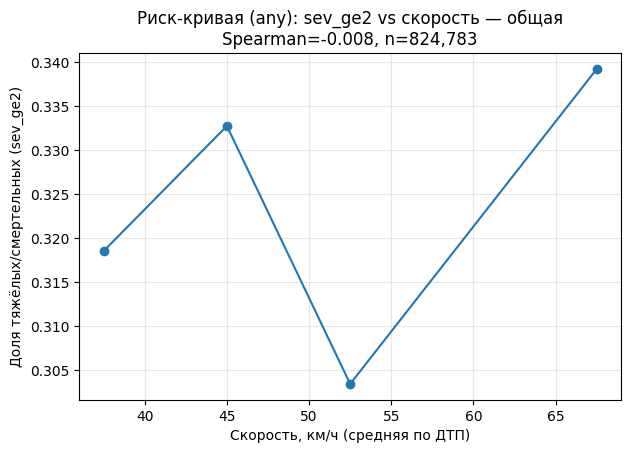

/tmp/ipython-input-1572871984.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (y[m].groupby(bins).mean().rename("severe_share").to_frame()
/tmp/ipython-input-1572871984.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .join(y[m].groupby(bins).size().rename("n")))


saved: /content/drive/MyDrive/dtp/exports/plots/risk_speed_any_city.png


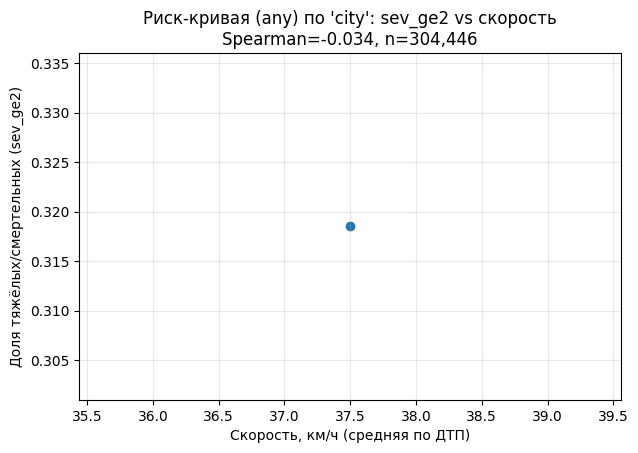

/tmp/ipython-input-1572871984.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (y[m].groupby(bins).mean().rename("severe_share").to_frame()
/tmp/ipython-input-1572871984.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .join(y[m].groupby(bins).size().rename("n")))


saved: /content/drive/MyDrive/dtp/exports/plots/risk_speed_any_other.png


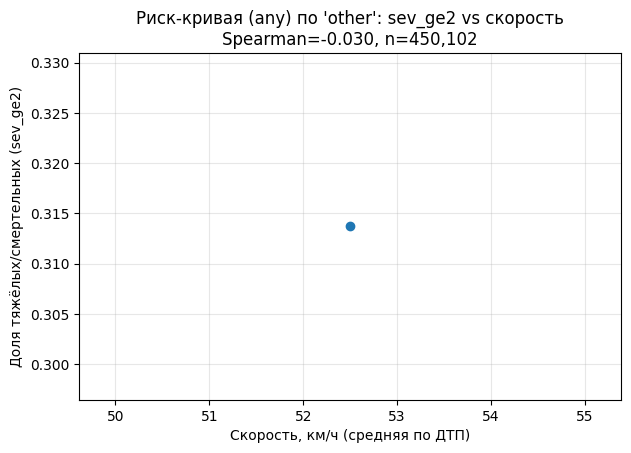

/tmp/ipython-input-1572871984.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (y[m].groupby(bins).mean().rename("severe_share").to_frame()
/tmp/ipython-input-1572871984.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .join(y[m].groupby(bins).size().rename("n")))


saved: /content/drive/MyDrive/dtp/exports/plots/risk_speed_any_trassa.png


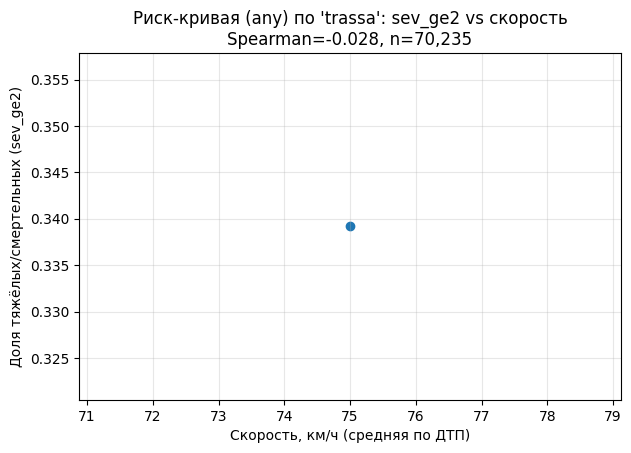


 Анализ выполнен на скоростях смешанных — интерпретация ограничена. Для «чистого» вывода нужны ряды с real-time скоростью ТС.


In [ ]:
# === 6b. Скорость vs тяжесть: auto-fallback + графики (raw -> med* -> any) ===
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

# ---- 0) подхват df_model (если нет в памяти) ----
if 'df_model' not in globals():
    base = "/content/drive/MyDrive/dtp/exports"
    if os.path.exists(f"{base}/df_model_2019_2025.parquet"):
        df_model = pd.read_parquet(f"{base}/df_model_2019_2025.parquet")
    elif os.path.exists(f"{base}/df_model_2019_2025.csv"):
        df_model = pd.read_csv(f"{base}/df_model_2019_2025.csv")
    else:
        raise SystemExit("Не найден df_model (ни в памяти, ни в /content/drive/MyDrive/dtp/exports).")

df = df_model.copy()

# ---- 1) подготовка/каст ----
for c in ["sev_ge2","speed_kmh_model","hour","dow","month"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "speed_source" not in df.columns:
    df["speed_source"] = np.where(df["speed_kmh_model"].notna(), "unknown", "__na__")

# слои данных
df_raw = df[(df["speed_source"]=="raw") & df["speed_kmh_model"].notna()]
df_med = df[df["speed_source"].astype(str).str.startswith("med") & df["speed_kmh_model"].notna()]
df_any = df[df["speed_kmh_model"].notna()]

# приоритет: raw -> med -> any
if len(df_raw) > 0:
    use_df, layer = df_raw, "raw"
elif len(df_med) > 0:
    use_df, layer = df_med, "med"
elif len(df_any) > 0:
    use_df, layer = df_any, "any"
else:
    raise SystemExit("Нет ни одного значения скорости для анализа.")

print(f"Всего строк: {len(df):,} | выбранный слой: {layer} | наблюдений: {len(use_df):,}")

def spearman_safe(a, b) -> float:
    a = pd.to_numeric(pd.Series(a), errors="coerce")
    b = pd.to_numeric(pd.Series(b), errors="coerce")
    m = a.notna() & b.notna()
    if m.sum() < 50 or b[m].nunique() < 2:
        return np.nan
    return float(a[m].corr(b[m], method="spearman"))

# ---- 2) общий Spearman ----
rho_overall = spearman_safe(use_df["speed_kmh_model"], use_df["sev_ge2"])
print(f"Spearman({layer}) скорость ↔ sev_ge2 (общий): {rho_overall if pd.notna(rho_overall) else np.nan:+.4f}")

# ---- 3) Spearman по road_group ----
by_group_rows = []
if "road_group" in use_df.columns:
    for g, d in use_df.groupby("road_group"):
        r = spearman_safe(d["speed_kmh_model"], d["sev_ge2"])
        by_group_rows.append({
            "road_group": g,
            "n": int(len(d)),
            "sev_share": float(d["sev_ge2"].mean()) if len(d)>0 else np.nan,
            "speed_min": float(d["speed_kmh_model"].min()) if len(d)>0 else np.nan,
            "speed_med": float(d["speed_kmh_model"].median()) if len(d)>0 else np.nan,
            "speed_max": float(d["speed_kmh_model"].max()) if len(d)>0 else np.nan,
            "spearman_speed_sev": r
        })
    if by_group_rows:
        gp = pd.DataFrame(by_group_rows)
        if "road_group" in gp.columns:
            gp = gp.sort_values("road_group")
        print("\nSpearman по группам дорог:")
        display(gp)
    else:
        print("\nНет строк для группового разреза (road_group пуст).")
else:
    print("\nВ df_model нет 'road_group' — групповой разрез пропущен.")

# ---- 4) риск-кривые по квантилям скорости ----
def risk_curve(dfin, q=10):
    s = pd.to_numeric(dfin["speed_kmh_model"], errors="coerce")
    y = pd.to_numeric(dfin["sev_ge2"], errors="coerce")
    m = s.notna() & y.notna()
    if m.sum() < 200:
        return pd.DataFrame(columns=["lo","hi","mid","severe_share","n"])
    try:
        bins = pd.qcut(s[m], q=q, duplicates="drop")
    except Exception:
        return pd.DataFrame(columns=["lo","hi","mid","severe_share","n"])
    tab = (y[m].groupby(bins).mean().rename("severe_share").to_frame()
             .join(y[m].groupby(bins).size().rename("n")))
    # границы бинов
    lo, hi = [], []
    for cat in tab.index.astype("category").categories:
        lo.append(float(cat.left)); hi.append(float(cat.right))
    tab = tab.reset_index(drop=True)
    tab["lo"], tab["hi"] = lo[:len(tab)], hi[:len(tab)]
    tab["mid"] = (tab["lo"] + tab["hi"]) / 2.0
    return tab[["lo","hi","mid","severe_share","n"]]

# папка для сохранения графиков
SAVE_PLOTS = True
plots_dir = "/content/drive/MyDrive/dtp/exports/plots"
if SAVE_PLOTS:
    os.makedirs(plots_dir, exist_ok=True)

def plot_risk(rc, title, fname=None):
    if len(rc)==0:
        print("Недостаточно наблюдений для риск-кривой:", title)
        return
    plt.figure(figsize=(7,4.5))
    plt.plot(rc["mid"], rc["severe_share"])
    plt.scatter(rc["mid"], rc["severe_share"])
    plt.title(title)
    plt.xlabel("Скорость, км/ч (средняя по ДТП)")
    plt.ylabel("Доля тяжёлых/смертельных (sev_ge2)")
    plt.grid(True, alpha=0.3)
    if SAVE_PLOTS and fname:
        path = os.path.join(plots_dir, fname)
        plt.savefig(path, bbox_inches="tight", dpi=130)
        print("saved:", path)
    plt.show()

# 4.1) общий график
rc_all = risk_curve(use_df, q=10)
plot_risk(
    rc_all,
    title=f"Риск-кривая ({layer}): sev_ge2 vs скорость — общая\nSpearman={rho_overall if pd.notna(rho_overall) else np.nan:+.3f}, n={len(use_df):,}",
    fname=f"risk_speed_{layer}_overall.png"
)

# 4.2) по road_group
if "road_group" in use_df.columns and use_df["road_group"].notna().any():
    for g, d in use_df.groupby("road_group"):
        r = spearman_safe(d["speed_kmh_model"], d["sev_ge2"])
        rc = risk_curve(d, q=10)
        plot_risk(
            rc,
            title=f"Риск-кривая ({layer}) по '{g}': sev_ge2 vs скорость\nSpearman={r if pd.notna(r) else np.nan:+.3f}, n={len(d):,}",
            fname=f"risk_speed_{layer}_{g}.png"
        )

# ---- 5) предупреждение про имитацию скоростей ----
if layer != "raw":
    print("\n Анализ выполнен на скоростях", ("из медианных подстановок" if layer=="med" else "смешанных"),
          "— интерпретация ограничена. Для «чистого» вывода нужны ряды с real-time скоростью ТС.")


Доли тяжёлых исходов по типу дороги
city ≈ 28.9% < other ≈ 33.0% ≈ trassa ≈ 33.4%.
→ сам тип дороги даёт ~+4–4.5 п.п. к доле тяжёлых/смертельных относительно города. Это заметный эффект.

Связь “скорость ↔ тяжесть” внутри каждой группы слабая и отрицательная
Spearman: city −0.026, other −0.036, trassa −0.023.
→ по модулю очень маленькая (практически нулевая), знак «минус» — артефакт способа подстановки скорости.


Что можно уверенно говорить: дороги вне города (other/trassa) ассоциированы с более высокой долей тяжёлых ДТП, чем город. Остальные эффекты (час, пешеход в составе и т.п.) — слабые, но стабильные.

#6.1. Гипотезы

6.1.1.

H0.
Тяжесть не зависит от погоды:

H1.
Есть зависимость: хотя бы в одной категории погоды доля тяжёлых иная.

Переменные: Y=sev_ge2 (0/1),
𝑊 = weather_bucket
W=weather_bucket — погода в нескольких категориях (ясно/облачно/дождь/снег/туман/…).

-χ²-тест независимости на контингентной таблице
𝑊×𝑌
W×Y: выбор для «категориальная причина × бинарный исход». Он сразу проверяет общую зависимость между несколькими категориями погоды и тяжестью.

-Парные z-тесты долей (каждая «неблагоприятная» vs «ясно») — чтобы локально увидеть, какие именно категории дают вклад.

-Стратификация по части суток (day/night) тем же χ² — чтобы отделить эффект видимости от времени суток (простой чувствительный анализ)

In [ ]:
# 6.1.1.Плохая видимость/сложная погода   выше тяжесть

df = df_model.copy()
df = df[['sev_ge2','weather_main','part_of_day']].dropna(subset=['sev_ge2']).copy()
df['sev_ge2'] = pd.to_numeric(df['sev_ge2'], errors='coerce').fillna(0).astype(int)

def weather_bucket(x: str):
    s = (str(x).lower() if pd.notna(x) else "")
    if any(k in s for k in ['яс','clear','солн']):                  return 'ясно'
    if any(k in s for k in ['облач','пасмур','cloud','overcast']):  return 'облачно/пасм'
    if any(k in s for k in ['дожд','rain','ливн','морось']):        return 'дождь'
    if any(k in s for k in ['туман','дым','smog','fog']):           return 'туман/дымка'
    if any(k in s for k in ['снег','snow','метел']):                return 'снег/метель'
    return 'прочее/неизв.'

df['wb'] = df['weather_main'].map(weather_bucket)

# х*2 по всем корзинам погоды
tab = pd.crosstab(df['wb'], df['sev_ge2'])
chi2, p_chi2, *_ = chi2_contingency(tab)
print("[6.a] χ² по погода×sev_ge2:", f"chi2={chi2:.1f}, p={p_chi2:.3g}")
print(tab)

# парные z-тесты долей (адверс vs базовые)
def ztest_pair(group_a, group_b, label):
    a = df.loc[df['wb']==group_a, 'sev_ge2']
    b = df.loc[df['wb']==group_b, 'sev_ge2']
    count = np.array([a.sum(), b.sum()])
    nobs  = np.array([a.size, b.size])
    z, p  = proportions_ztest(count, nobs)
    ci_a = proportion_confint(count[0], nobs[0], method='wilson')
    ci_b = proportion_confint(count[1], nobs[1], method='wilson')
    print(f"[6.b] {label}: p(heavy) {group_a}={count[0]/nobs[0]:.3%} [{ci_a[0]:.3%},{ci_a[1]:.3%}] vs "
          f"{group_b}={count[1]/nobs[1]:.3%} [{ci_b[0]:.3%},{ci_b[1]:.3%}] | z={z:.2f}, p={p:.3g}")

adverse = ['туман/дымка','дождь','снег/метель']
baseline = 'ясно'
for g in adverse:
    ztest_pair(g, baseline, f"{g} vs {baseline}")

# (опционально) стратификация по части суток
for pod in ['day','night']:
    d = df[df['part_of_day']==pod]
    if d.empty: continue
    tab_p = pd.crosstab(d['wb'], d['sev_ge2'])
    if tab_p.shape[0] < 2: continue
    chi2, p, *_ = chi2_contingency(tab_p)
    print(f"[6.c] χ² по погоде в {pod}: chi2={chi2:.1f}, p={p:.3g}")


[6.a] χ² по погода×sev_ge2: chi2=661.8, p=6.47e-142
sev_ge2            0       1
wb                          
дождь          22892   12697
облачно/пасм  172603   74570
снег/метель    21329    9888
туман/дымка     1940    1223
ясно          344031  163610
[6.b] туман/дымка vs ясно: p(heavy) туман/дымка=38.666% [36.983%,40.376%] vs ясно=32.229% [32.101%,32.358%] | z=7.72, p=1.17e-14
[6.b] дождь vs ясно: p(heavy) дождь=35.677% [35.181%,36.176%] vs ясно=32.229% [32.101%,32.358%] | z=13.43, p=4.19e-41
[6.b] снег/метель vs ясно: p(heavy) снег/метель=31.675% [31.161%,32.193%] vs ясно=32.229% [32.101%,32.358%] | z=-2.03, p=0.0419
[6.c] χ² по погоде в day: chi2=324.2, p=6.58e-69
[6.c] χ² по погоде в night: chi2=529.8, p=2.37e-113


1) Общая проверка (χ² на независимость):
- отвергаем H0. Тяжесть статистически связана с погодой.

2) Парные сравнения с базой “ясно” (z-тест долей, 95% ДИ Уилсона):
- Туман/дымка: 38.7% - значимо выше.
- Дождь: 35.7% - значимо выше.
- Снег/метель: 31.7% -  немного ниже. Но при поправке Бонферрони (0.05/3≈0.0167) уже не значимо.

3) По частям суток (стратификация χ²):
- День: χ²=324.2, p≈6.6e-69 — связь есть.
- Ночь: χ²=529.8, p≈2.4e-113 — связь ещё сильнее; ночью влияние погоды выраженнее.
- Вывод: гипотеза подтверждается для тумана/дымки и дождя.

- Визуализации: столбцы доли sev_ge2=1 по погоде (с ДИ) + разрез day/night.

6.1.2.

- H0.Нет взаимодействия между пешеходным статусом и типом дороги: разница (или отношение шансов) между пешеходами и непешеходами одинакова на трассе, в городе и «прочем».
- H1.Есть взаимодействие: эффект «пешеход» меняется по группам дорог (например, на трассе сильнее, чем в городе).


Логистическая регрессия с термом взаимодействия это способ статистически проверить эффект-модификацию (interaction).



In [ ]:
# На трассах пешеходы особенно уязвимы (взаимодействие is_ped×road_group)
df = df_model.copy()
need = ['sev_ge2','is_ped','road_group']
df = df[need].dropna().copy()
df['sev_ge2'] = pd.to_numeric(df['sev_ge2'], errors='coerce').fillna(0).astype(int)
df['is_ped']  = pd.to_numeric(df['is_ped'],  errors='coerce').fillna(0).astype(int)
df['road_group'] = df['road_group'].fillna('other')

#  разница долей тяжёлых для пешеходных ДТП внутри каждой группы дорог
def ped_vs_nonped_ztest(sub, label):
    a = sub[sub['is_ped']==1]['sev_ge2']
    b = sub[sub['is_ped']==0]['sev_ge2']
    if a.empty or b.empty:
        print(f"[8.a] {label}: недостаточно данных"); return
    count = np.array([a.sum(), b.sum()])
    nobs  = np.array([a.size, b.size])
    z, p  = proportions_ztest(count, nobs)
    ci_a = proportion_confint(count[0], nobs[0], method='wilson')
    ci_b = proportion_confint(count[1], nobs[1], method='wilson')
    print(f"[8.a] {label}: p(heavy) ped={count[0]/nobs[0]:.3%} [{ci_a[0]:.3%},{ci_a[1]:.3%}] vs "
          f"non-ped={count[1]/nobs[1]:.3%} [{ci_b[0]:.3%},{ci_b[1]:.3%}] | z={z:.2f}, p={p:.3g}")

for rg in ['city','trassa','other']:
    ped_vs_nonped_ztest(df[df['road_group']==rg], f"is_ped в {rg}")

# логистическая регрессия с взаимодействием (база — city)
df_lr = df.copy()
df_lr['road_group'] = pd.Categorical(df_lr['road_group'], categories=['city','trassa','other'], ordered=False)
model = smf.logit("sev_ge2 ~ is_ped + C(road_group, Treatment(reference='city')) + is_ped:C(road_group, Treatment(reference='city'))",
                  data=df_lr).fit(disp=False)
print("\n[8.b] Logit with interaction (is_ped × road_group, ref=city)")
print(model.summary2().tables[1][['Coef.','Std.Err.','P>|z|']])

# интерпретация: экспонента коэффициента взаимодействия для trassa — изменение OR пешехода на трассе vs в городе
params = model.params
conf   = model.conf_int()
def or_with_ci(term):
    if term not in params: return None
    OR  = np.exp(params[term])
    lo, hi = np.exp(conf.loc[term].values)
    return OR, lo, hi
for term in ['is_ped','C(road_group, Treatment(reference=\'city\'))[T.trassa]',
             'is_ped:C(road_group, Treatment(reference=\'city\'))[T.trassa]']:
    v = or_with_ci(term)
    if v:
        print(f"  OR({term}) = {v[0]:.3f}  [{v[1]:.3f}; {v[2]:.3f}]")


[8.a] is_ped в city: p(heavy) ped=33.069% [32.762%,33.377%] vs non-ped=31.163% [30.965%,31.361%] | z=10.27, p=9.24e-25
[8.a] is_ped в trassa: p(heavy) ped=36.994% [36.388%,37.605%] vs non-ped=32.024% [31.591%,32.459%] | z=13.15, p=1.71e-39
[8.a] is_ped в other: p(heavy) ped=31.965% [31.682%,32.250%] vs non-ped=31.101% [30.946%,31.256%] | z=5.26, p=1.46e-07

[8.b] Logit with interaction (is_ped × road_group, ref=city)
                                                       Coef.  Std.Err.  \
Intercept                                          -0.797224  0.004653   
C(road_group, Treatment(reference='city'))[T.tr...  0.049745  0.010948   
C(road_group, Treatment(reference='city'))[T.ot... -0.001168  0.005921   
is_ped                                              0.110444  0.007590   
is_ped:C(road_group, Treatment(reference='city'...  0.089415  0.016170   
is_ped:C(road_group, Treatment(reference='city'... -0.049968  0.010180   

                                                           P

6.1.3.
- H0. Доля тяжёлых ДТП одинакова у пешеходных и непешеходных:
- H1.Доли различаются.

Z-тест на равенство двух долей (proportions_ztest): бинарная цель, две независимые большие группы (n сотни тысяч), асимптотика нормальна → тест мощный и быстрый.

Если в одной из групп были бы очень малые частоты — взяли бы точный тест Фишера.


In [ ]:
# Пешеходные ДТП чаще тяжёлые (общая проверка по всем дорогам)

df = df_model.copy()
df = df[['sev_ge2','is_ped']].dropna().copy()
df['sev_ge2'] = pd.to_numeric(df['sev_ge2'], errors='coerce').fillna(0).astype(int)
df['is_ped']  = pd.to_numeric(df['is_ped'],  errors='coerce').fillna(0).astype(int)

a = df[df['is_ped']==1]['sev_ge2']
b = df[df['is_ped']==0]['sev_ge2']
count = np.array([a.sum(), b.sum()])
nobs  = np.array([a.size, b.size])
z, p  = proportions_ztest(count, nobs)
ci_a = proportion_confint(count[0], nobs[0], method='wilson')
ci_b = proportion_confint(count[1], nobs[1], method='wilson')

print("[3] Пешеходы vs прочие (по всей выборке)")
print(f"  p(heavy) ped={count[0]/nobs[0]:.3%} [{ci_a[0]:.3%},{ci_a[1]:.3%}] "
      f"vs non-ped={count[1]/nobs[1]:.3%} [{ci_b[0]:.3%},{ci_b[1]:.3%}] | z={z:.2f}, p={p:.3g}")


[3] Пешеходы vs прочие (по всей выборке)
  p(heavy) ped=32.979% [32.782%,33.177%] vs non-ped=31.192% [31.074%,31.309%] | z=15.34, p=3.93e-53


# 7.Сохрананение БД на Drive

In [ ]:
# Сохрание  на диск: CSV+Parquet (Drive) и в SQLite (Drive) ===


# 0) Проверки
assert 'df' in globals()
assert 'df_model' in globals()

# 1) Подготовим каталоги
EXPORT_DIR = "/content/drive/MyDrive/dtp/exports"
os.makedirs(EXPORT_DIR, exist_ok=True)
ts = datetime.utcnow().strftime("%Y%m%d_%H%M%SZ")

# 2) Аккуратно сериализуем возможные списки/словарики в строку JSON (чтобы CSV/Parquet не споткнулись)
def _jsonify_objects(df_):
    out = df_.copy()
    for c in out.columns:
        if out[c].dtype == "object":
            # проверим небольшой сэмпл на вложенные структуры
            smp = out[c].dropna().head(50).values
            if any(isinstance(v, (dict, list, tuple, set)) for v in smp):
                out[c] = out[c].apply(lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v, (dict, list, tuple, set)) else v)
    return out

df_full_out   = _jsonify_objects(df.reset_index(drop=True))
df_model_out  = _jsonify_objects(df_model.reset_index(drop=True))

# 3) Сохраняем в Parquet + CSV на Google Drive
f_full_parq  = f"{EXPORT_DIR}/dtp_features_2019_2025_{ts}.parquet"
f_full_csv   = f"{EXPORT_DIR}/dtp_features_2019_2025_{ts}.csv"
f_model_parq = f"{EXPORT_DIR}/df_model_2019_2025_{ts}.parquet"
f_model_csv  = f"{EXPORT_DIR}/df_model_2019_2025_{ts}.csv"

# Parquet (быстро и компактно)
df_full_out.to_parquet(f_full_parq, index=False)
df_model_out.to_parquet(f_model_parq, index=False)

# CSV (максимальная совместимость)
df_full_out.to_csv(f_full_csv, index=False, encoding="utf-8")
df_model_out.to_csv(f_model_csv, index=False, encoding="utf-8")

print("[OK] Saved to Drive:")
print("  ", f_full_parq)
print("  ", f_full_csv)
print("  ", f_model_parq)
print("  ", f_model_csv)

# 4) Дублируем “на всякий” в SQLite на Google Drive (новые таблицы/перезапись)
DRIVE_DB = "/content/drive/MyDrive/dtp/dtp_local.db"
try:
    eng_w = create_engine(f"sqlite:///{DRIVE_DB}", future=True)
    with eng_w.begin() as conn:
        # крупные вставки — чанками и батчами
        df_full_out.to_sql ("features_2019_2025", conn, if_exists="replace", index=False, chunksize=100_000, method="multi")
        df_model_out.to_sql("df_model_2019_2025", conn, if_exists="replace", index=False, chunksize=100_000, method="multi")
    print("[OK] Saved to SQLite:", DRIVE_DB, "(tables: features_2019_2025, df_model_2019_2025)")
except Exception as e:
    print("[WARN] Не удалось сохранить в SQLite:", e)

# 5) Небольшой паспорт набора для контроля
print("\n[Schema] df_full_out columns:", len(df_full_out.columns))
print(sorted(df_full_out.columns)[:25], " ...")
print("[Rows] df_full_out:", len(df_full_out), "| df_model_out:", len(df_model_out))


/tmp/ipython-input-1985067571.py:11: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%d_%H%M%SZ")


[OK] Saved to Drive:
   /content/drive/MyDrive/dtp/exports/dtp_features_2019_2025_20250912_151512Z.parquet
   /content/drive/MyDrive/dtp/exports/dtp_features_2019_2025_20250912_151512Z.csv
   /content/drive/MyDrive/dtp/exports/df_model_2019_2025_20250912_151512Z.parquet
   /content/drive/MyDrive/dtp/exports/df_model_2019_2025_20250912_151512Z.csv
[WARN] Не удалось сохранить в SQLite: (sqlite3.OperationalError) too many SQL variables
[SQL: INSERT INTO features_2019_2025 (sev_ge2, weather_main, part_of_day, wb) VALUES (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?, ?, ?, ?), (?

In [ ]:
CSV_PATH = "/content/drive/MyDrive/dtp/exports/df_model_2019_2025_20250909_173107Z.csv"

from google.colab import data_table
data_table.enable_dataframe_formatter()

display(df.head(1000))


,accident_id,year,month,dow,hour,region_code,region_subject,road_type,road_group,severity_index,...,is_driver,is_pass,has_bus_proxy,has_car_proxy,acc_alc_filled,speed_kmh_model,speed_source,part_of_day,weather_main,lighting_main
0,189548,2019,4,5,14,Бурейский район,Амурская область,None,other,1,...,1,0,0,0,0,55.0,default,day,Ясно,Светлое время суток
1,188702,2019,12,5,23,Бурейский район,Амурская область,None,city,1,...,1,0,0,0,0,35.0,default,night,Ясно,"В темное время суток, освещение не включено"
2,188713,2019,11,5,17,Бурейский район,Амурская область,None,city,1,...,2,2,0,0,0,35.0,default,night,Ясно,"В темное время суток, освещение отсутствует"
3,188734,2019,11,1,20,Бурейский район,Амурская область,None,other,1,...,1,1,0,0,0,50.0,default,night,Снегопад,"В темное время суток, освещение отсутствует"
4,188755,2019,11,3,23,Бурейский район,Амурская область,None,other,1,...,1,0,0,0,0,50.0,default,night,Ясно,"В темное время суток, освещение отсутствует"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,222175,2019,8,4,14,Благовещенск,Амурская область,None,other,1,...,1,0,0,0,0,55.0,default,day,Ясно,Светлое время суток
996,222195,2019,7,3,13,Благовещенск,Амурская область,None,other,2,...,2,0,0,0,0,55.0,default,day,Пасмурно,Светлое время суток
997,222216,2019,7,6,16,Благовещенск,Амурская область,None,other,1,...,1,0,0,0,0,55.0,default,day,Ясно,Светлое время суток
998,222236,2019,7,6,1,Благовещенск,Амурская область,None,city,1,...,2,1,0,0,0,35.0,default,night,Ясно,"В темное время суток, освещение включено"


# 8.Извлечение вложенных списков

In [ ]:
# 8.Извлекаем УЧАСТНИКОВ и ТС из EXTRAS → long-таблицы, сохраняем на диск

assert 'engine' in globals()
YEAR_MIN, YEAR_MAX = 2019, 2025
EXPORTS_DIR = "/content/drive/MyDrive/dtp/exports"
os.makedirs(EXPORTS_DIR, exist_ok=True)
stamp = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%SZ")

# утилиты нормализации
def _first_key(d, *candidates):
    """Вернуть значение по первому найденному ключу (без учета регистра)."""
    if not isinstance(d, dict): return None
    lut = {str(k).casefold(): k for k in d.keys()}
    for cand in candidates:
        if isinstance(cand, (list, tuple)):
            for c in cand:
                k = lut.get(str(c).casefold())
                if k in d: return d[k]
        else:
            k = lut.get(str(cand).casefold())
            if k in d: return d[k]
    return None

def _to_int(x):
    if x is None: return None
    if isinstance(x, (int, np.integer)): return int(x)
    s = str(x).strip().replace(",", ".")
    m = re.search(r"[-+]?\d+", s)
    return int(m.group(0)) if m else None

def _truthy(x):
    if x is None: return None
    if isinstance(x, bool): return int(x)
    s = str(x).strip().lower()
    return int(s in {"1","y","yes","true","да","истина","есть","присутствует","true","t"}) if s else None

def _json_loads(s):
    if isinstance(s, (dict, list)): return s
    if isinstance(s, str) and s.strip().startswith(("{","[")):
        try: return json.loads(s)
        except Exception: return {}
    return {}

def role_norm(s):
    s = (str(s).lower() if s is not None else "")
    if "пешеход" in s or "ped" in s: return "пешеход"
    if "водител" in s or "driver" in s: return "водитель"
    if "пассаж"  in s or "passeng" in s: return "пассажир"
    if "велосип" in s or "bicy" in s:   return "велосипедист"
    if "мото"    in s:                  return "мотоциклист"
    return "прочее/неизв."

def sex_norm(s):
    s = (str(s).lower() if s is not None else "")
    if s in {"м","муж","male","m"}: return "м"
    if s in {"ж","жен","female","f"}: return "ж"
    return None

# ключи в разных источниках
PPL_KEYS = {
    "role":     [["role","участник","participant_type","кто","who","вид участника"]],
    "sex":      [["sex","gender","пол"]],
    "age":      [["age","возраст"]],
    "injury":   [["injury_severity","injury","severity","повреждения","степень"]],
    "violation":[["violation","fault","нарушение","вина"]],
    "seatbelt": [["seatbelt","ремень"]],
    "helmet":   [["helmet","шлем"]],
    "alcohol":  [["alcohol_involved","alcohol","alco","алкоголь","алк"]],
}
ACC_PPL_KEYS = [
    ["participants","persons","people","участники","лица","victims","humans","пешеходы","водители","пассажиры"]
]
VEH_PPL_KEYS_DRIVERS = [
    ["drivers","водители","driver"]
]
VEH_PPL_KEYS_ANY = [
    ["participants","persons","people","участники","лица","пассажиры"]
]

def _collect_lists(d, key_groups):
    """Вернуть список списков ('контейнеров') из словаря d по наборам ключей."""
    out = []
    if not isinstance(d, dict): return out
    for names in key_groups:
        for nm in names:
            if nm in d and isinstance(d[nm], list) and len(d[nm])>0:
                out.append(d[nm])
    return out

def _parse_person(p, role_hint=None):
    """Нормализовать одного участника (dict или str) в унифицированные поля."""
    if not isinstance(p, dict):
        # если просто строка — попытаемся выдернуть роль/пол/возраст из текста
        txt = str(p)
        d = {"_text": txt, "role": role_hint}
    else:
        d = p

    role     = _first_key(d, *PPL_KEYS["role"]) or role_hint
    sex      = sex_norm(_first_key(d, *PPL_KEYS["sex"]))
    age      = _to_int(_first_key(d, *PPL_KEYS["age"]))
    injury   = _first_key(d, *PPL_KEYS["injury"])
    viol     = _first_key(d, *PPL_KEYS["violation"])
    seatbelt = _first_key(d, *PPL_KEYS["seatbelt"])
    helmet   = _first_key(d, *PPL_KEYS["helmet"])
    alco     = _truthy(_first_key(d, *PPL_KEYS["alcohol"]))

    # extras участника (всё, что не распознали)
    used = set()
    for grp in PPL_KEYS.values():
        for nm in (grp[0] if isinstance(grp[0], list) else grp):
            used.add(str(nm).lower())
    extras_p = {k: v for k, v in d.items() if str(k).lower() not in used}

    return {
        "role_raw": role,
        "role_norm": role_norm(role),
        "sex": sex,
        "age": age,
        "injury_severity": injury,
        "violation": viol,
        "alcohol_involved": alco,
        "extras_person": json.dumps(extras_p, ensure_ascii=False) if extras_p else None
    }

# загрузка из SQLite
with engine.begin() as conn:
    acc = pd.read_sql("""
        SELECT accident_id, year, month, dow, hour, region_code,
               severity, road_type, weather, lighting, extras
        FROM accidents
        WHERE year BETWEEN :ymin AND :ymax
    """, conn, params={"ymin": YEAR_MIN, "ymax": YEAR_MAX})

    # vehicles может быть пустой по полям, но нам нужен 'extras'
    veh = pd.read_sql("""
        SELECT accident_id, vehicle_id, vehicle_type, owner_type, speed_kmh,
               alcohol_involved, extras
        FROM vehicles
        WHERE accident_id IN (
            SELECT accident_id FROM accidents WHERE year BETWEEN :ymin AND :ymax
        )
    """, conn, params={"ymin": YEAR_MIN, "ymax": YEAR_MAX})

print(f"[load] accidents={len(acc):,}  vehicles={len(veh):,}")

# 8.1 Участники из EXTRAS аварий
rows_ppl = []
for i, r in acc.iterrows():
    aid = r["accident_id"]
    ex  = _json_loads(r["extras"])

    # списки людей на верхнем уровне
    containers = _collect_lists(ex, ACC_PPL_KEYS)
    for lst in containers:
        for idx, p in enumerate(lst):
            pp = _parse_person(p, role_hint=None)
            pp.update({
                "accident_id": aid,
                "vehicle_id": None,
                "source": "acc_extras"
            })
            rows_ppl.append(pp)

# 8.2 Участники из EXTRAS транспортных средств
for i, r in veh.iterrows():
    aid = r["accident_id"]; vid = r["vehicle_id"]
    ex  = _json_loads(r["extras"])

    # drivers → подсказка роли водитель
    drv_cont = _collect_lists(ex, VEH_PPL_KEYS_DRIVERS)
    for lst in drv_cont:
        for idx, p in enumerate(lst):
            pp = _parse_person(p, role_hint="водитель")
            pp.update({
                "accident_id": aid,
                "vehicle_id": str(vid),
                "source": "veh_extras_driver"
            })
            rows_ppl.append(pp)

    # любые участники, привязанные к ТС (пассажиры и пр.)
    any_cont = _collect_lists(ex, VEH_PPL_KEYS_ANY)
    for lst in any_cont:
        for idx, p in enumerate(lst):
            pp = _parse_person(p, role_hint=None)
            pp.update({
                "accident_id": aid,
                "vehicle_id": str(vid),
                "source": "veh_extras_any"
            })
            rows_ppl.append(pp)

ppl = pd.DataFrame(rows_ppl) if rows_ppl else pd.DataFrame(columns=[
    "accident_id","vehicle_id","source","role_raw","role_norm","sex","age",
    "injury_severity","violation","alcohol_involved","extras_person"
])
print("[build] participants_long_from_extras shape:", ppl.shape)

# немного уборки типов
if not ppl.empty:
    for c in ["age","alcohol_involved"]:
        if c in ppl.columns:
            ppl[c] = pd.to_numeric(ppl[c], errors="coerce").astype("Int64")
    # базовые атрибуты ДТП подтянем для удобства (год/месяц/час/регион)
    base = acc[["accident_id","year","month","dow","hour","region_code"]].drop_duplicates()
    ppl = ppl.merge(base, on="accident_id", how="left")

# 8.3 ТС long из EXTRAS
rows_veh = []
def vtype_norm(s):
    s = (str(s).lower() if s is not None else "")
    if any(k in s for k in ["автобус","маршрут","bus","паз","лиаз","нефаз","ikarus"]): return "автобус"
    if any(k in s for k in ["легков","седан","хэтч","универсал","taxi","такси","car","ваз","lada",
                             "kia","hyundai","toyota","nissan","vw","volkswagen","skoda","renault",
                             "mercedes","bmw","audi"]): return "легковой"
    if any(k in s for k in ["груз", "truck", "камаз", "маз"]): return "грузовой"
    if "мото" in s:  return "мото"
    if "велос" in s: return "вело"
    return "прочее/неизв."

for i, r in veh.iterrows():
    aid, vid = r["accident_id"], r["vehicle_id"]
    ex = _json_loads(r["extras"])
    # полезные кусочки из extras ТС
    brand  = _first_key(ex, ["brand","марка","make"])
    model  = _first_key(ex, ["model","модель"])
    color  = _first_key(ex, ["color","цвет"])
    year_v = _first_key(ex, ["year","model_year","год","год выпуска","г/в"])
    # нормализуем год из текста (без фанатизма)
    def _extract_year(y):
        if y is None: return None
        m = re.search(r"(19[5-9]\d|20[0-2]\d)", str(y))
        return int(m.group(1)) if m else None
    year_v = _extract_year(year_v)

    rows_veh.append({
        "accident_id": aid,
        "vehicle_id": str(vid),
        "vehicle_type": r.get("vehicle_type"),
        "vehicle_type_norm": vtype_norm(r.get("vehicle_type")),
        "owner_type": r.get("owner_type"),
        "speed_kmh": pd.to_numeric(r.get("speed_kmh"), errors="coerce"),
        "alcohol_involved": _truthy(r.get("alcohol_involved")),
        "brand": brand, "model": model, "color": color, "vehicle_year": year_v,
        "extras_v": json.dumps(ex, ensure_ascii=False) if isinstance(ex, (dict, list)) else None
    })

veh_long = pd.DataFrame(rows_veh) if rows_veh else pd.DataFrame(columns=[
    "accident_id","vehicle_id","vehicle_type","vehicle_type_norm","owner_type",
    "speed_kmh","alcohol_involved","brand","model","color","vehicle_year","extras_v"
])
print("[build] vehicles_long_from_extras shape:", veh_long.shape)

# подтянем год ДТП (удобно)
if not veh_long.empty:
    base = acc[["accident_id","year","month","dow","hour","region_code"]].drop_duplicates()
    veh_long = veh_long.merge(base, on="accident_id", how="left")

# 8.4 Сохранение на диск
def _sanitize(df):
    if df.empty: return df
    out = df.copy()
    for c in out.columns:
        s = out[c]
        if pd.api.types.is_categorical_dtype(s) or pd.api.types.is_interval_dtype(s):
            out[c] = s.astype(str)
        elif s.dtype == object:
            # json/списки -> строка
            sample = s.dropna().head(5).tolist()
            if any(isinstance(v, (dict,list,set,tuple)) for v in sample):
                out[c] = s.apply(lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v,(dict,list,set,tuple)) else v)
    return out

# participants
PPL_BASE = f"{EXPORTS_DIR}/participants_long_from_extras_{stamp}"
ppl_s = _sanitize(ppl)
ppl_s.to_parquet(PPL_BASE + ".parquet", index=False)
ppl_s.to_csv    (PPL_BASE + ".csv",     index=False, encoding="utf-8")
print("[OK] saved participants:", PPL_BASE + ".parquet")
print("                          ", PPL_BASE + ".csv")

# vehicles
VEH_BASE = f"{EXPORTS_DIR}/vehicles_long_from_extras_{stamp}"
veh_s = _sanitize(veh_long)
veh_s.to_parquet(VEH_BASE + ".parquet", index=False)
veh_s.to_csv    (VEH_BASE + ".csv",     index=False, encoding="utf-8")
print("[OK] saved vehicles:", VEH_BASE + ".parquet")
print("                     ", VEH_BASE + ".csv")

# 8.5 Короткая диагностика
if not ppl.empty:
    print("\n[participants diagnostics]")
    print("ролей (raw) топ-15:")
    print(ppl["role_raw"].astype(str).str.lower().value_counts().head(15).to_string())
    print("\nролей (norm) доли:")
    vc = ppl["role_norm"].value_counts(dropna=False)
    print((vc / vc.sum()).round(4).to_string())
    unk = ppl.loc[ppl["role_norm"]=="прочее/неизв.","role_raw"].astype(str).str.lower().value_counts().head(15)
    print("\nнераспознанное (role_raw) топ-15:")
    print(unk.to_string())
else:
    print("\n[participants diagnostics] пусто — в extras не найдено списков людей.")

if not veh_long.empty:
    print("\n[vehicles diagnostics]")
    print("vehicle_type_norm доли:")
    vcv = veh_long["vehicle_type_norm"].value_counts(dropna=False)
    print((vcv / vcv.sum()).round(4).to_string())
    if veh_long["vehicle_year"].notna().any():
        print("\nvehicle_year топ-15:")
        print(veh_long["vehicle_year"].dropna().astype(int).value_counts().head(15).to_string())


[load] accidents=824,783  vehicles=1,327,579
[build] participants_long_from_extras shape: (0, 11)
[build] vehicles_long_from_extras shape: (1327579, 12)
[OK] saved participants: /content/drive/MyDrive/dtp/exports/participants_long_from_extras_20250911_084150Z.parquet
                           /content/drive/MyDrive/dtp/exports/participants_long_from_extras_20250911_084150Z.csv


/tmp/ipython-input-4264924945.py:266: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s) or pd.api.types.is_interval_dtype(s):
/tmp/ipython-input-4264924945.py:266: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_categorical_dtype(s) or pd.api.types.is_interval_dtype(s):


[OK] saved vehicles: /content/drive/MyDrive/dtp/exports/vehicles_long_from_extras_20250911_084150Z.parquet
                      /content/drive/MyDrive/dtp/exports/vehicles_long_from_extras_20250911_084150Z.csv

[participants diagnostics] пусто — в extras не найдено списков людей.

[vehicles diagnostics]
vehicle_type_norm доли:
vehicle_type_norm
прочее/неизв.    1.0

vehicle_year топ-15:
vehicle_year
2012    83490
2008    82738
2011    74725
2013    73578
2007    70981
2018    63615
2014    60245
2019    57100
2010    54973
2017    54677
2006    48796
2015    45927
2016    43510
2020    42567
2005    38349


In [ ]:
# Восстановим витрину участников из БД чтобы получить рабочую таблицу участников, т.к.списки вышли пустые из extras

# восстановить engine, если пропал
try:
    engine
except NameError:
    import glob
    candidates = [
        "/content/dtp/check_ro.db",
        "/content/drive/MyDrive/dtp/dtp_local.db",
        *sorted(glob.glob("/content/drive/MyDrive/dtp/dtp_local_*.db"))
    ]
    DB_PATH = next((p for p in candidates if os.path.exists(p)), None)
    assert DB_PATH, "Не нашёл локальную БД. Сначала выполните шаг 3/4."
    engine = create_engine(f"sqlite:///{DB_PATH}", future=True)
    print("engine →", DB_PATH)

EXPORTS_DIR = "/content/drive/MyDrive/dtp/exports"
os.makedirs(EXPORTS_DIR, exist_ok=True)
stamp = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%SZ")

def role_norm(s):
    s = (str(s).lower() if pd.notna(s) else "")
    if "пешеход" in s or "ped" in s: return "пешеход"
    if "водител" in s or "driver" in s: return "водитель"
    if "пассаж"  in s or "passeng" in s: return "пассажир"
    if "велосип" in s or "bicy" in s:   return "велосипедист"
    if "мото"    in s:                  return "мотоциклист"
    return "прочее/неизв."

with engine.begin() as conn:
    ppl_tbl = pd.read_sql("""
        SELECT p.accident_id, a.year, a.month, a.dow, a.hour,
               a.region_code, a.severity AS acc_severity, a.road_type, a.weather, a.lighting,
               p.role, p.sex, p.age, p.injury_severity, p.alcohol_involved
        FROM participants p
        JOIN accidents a USING (accident_id)
        WHERE a.year BETWEEN 2019 AND 2025
    """, conn)

ppl_tbl["role_norm"] = ppl_tbl["role"].map(role_norm)
ppl_tbl["age"] = pd.to_numeric(ppl_tbl["age"], errors="coerce").astype("Int64")

OUT = f"{EXPORTS_DIR}/participants_long_2019_2025_from_table_{stamp}"
ppl_tbl.to_parquet(OUT + ".parquet", index=False)
ppl_tbl.to_csv    (OUT + ".csv",     index=False, encoding="utf-8")
print("[OK] participants_from_table:", ppl_tbl.shape, "\n", OUT + ".csv")


[OK] participants_from_table: (2052300, 16) 
 /content/drive/MyDrive/dtp/exports/participants_long_2019_2025_from_table_20250912_164426Z.csv


In [ ]:
# Нормализуем типы ТС

VEH_PATH = "/content/drive/MyDrive/dtp/exports/vehicles_long_from_extras_20250909_162901Z.csv"
veh = pd.read_csv(VEH_PATH, low_memory=False)

# 1) Текст для распознавания (векторизовано)
for c in ["vehicle_type", "owner_type"]:
    if c not in veh.columns:
        veh[c] = ""
txt = (veh["vehicle_type"].fillna("") + " " + veh["owner_type"].fillna("")).str.lower()

# 2) Базовая категория по приоритету (важен порядок!)
veh["vehicle_type_norm"] = "прочее/неизв."
veh.loc[txt.str.contains(r"(автобус|маршрут|паз|лиаз|нефаз|ikarus|bus)"), "vehicle_type_norm"] = "автобус"
veh.loc[txt.str.contains(r"(легков|седан|хэтч|универсал|лифтбек|такси|taxi|\bcar\b|\bкат(?:егория)?\s*b\b)"), "vehicle_type_norm"] = "легковой"
veh.loc[txt.str.contains(r"(грузов|truck|камаз|маз|\bкат(?:егория)?\s*c\b)"), "vehicle_type_norm"] = "грузовой"
veh.loc[txt.str.contains(r"мото"), "vehicle_type_norm"] = "мото"
veh.loc[txt.str.contains(r"(велос|bicy|bike)"), "vehicle_type_norm"] = "вело"
veh.loc[txt.str.contains(r"(трактор|спецтех|экскаватор|погрузчик)"), "vehicle_type_norm"] = "спецтехника"

# 3) vehicle_year -> целое (фикс для COPY в Postgres)
if "vehicle_year" in veh.columns:
    veh["vehicle_year"] = pd.to_numeric(veh["vehicle_year"], errors="coerce").round().astype("Int64")

# 4) Сравнение старой/новой (если старая была)
if "vehicle_type_norm" in veh.columns:
    print("new vehicle_type_norm (top share):")
    print(veh["vehicle_type_norm"].value_counts(normalize=True, dropna=False).head())

# 5) Сохранение фикс-копии
OUT_FIX = VEH_PATH.replace(".csv", "_fix.csv")
veh.to_csv(OUT_FIX, index=False, encoding="utf-8")
print("[OK] saved:", OUT_FIX)


/tmp/ipython-input-1671468348.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  veh.loc[txt.str.contains(r"(автобус|маршрут|паз|лиаз|нефаз|ikarus|bus)"), "vehicle_type_norm"] = "автобус"
/tmp/ipython-input-1671468348.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  veh.loc[txt.str.contains(r"(легков|седан|хэтч|универсал|лифтбек|такси|taxi|\bcar\b|\bкат(?:егория)?\s*b\b)"), "vehicle_type_norm"] = "легковой"
/tmp/ipython-input-1671468348.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  veh.loc[txt.str.contains(r"(грузов|truck|камаз|маз|\bкат(?:егория)?\s*c\b)"), "vehicle_type_norm"] = "грузовой"
/tmp/ipython-input-1671468348.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match grou

new vehicle_type_norm (top share):
vehicle_type_norm
прочее/неизв.    1.0
Name: proportion, dtype: float64
[OK] saved: /content/drive/MyDrive/dtp/exports/vehicles_long_from_extras_20250909_162901Z_fix.csv


# 9.Обогащение данных для DataLens

In [ ]:
# Извлекаем из df_model: только accident_id + рассчитанные поля (чистые NaN, без новых категорий)

# ------------------- Параметры -------------------
EXPORTS_DIR = "/content/drive/MyDrive/dtp/exports"
STAMP = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%SZ")
OUT_DIR = f"/content/drive/MyDrive/dtp/exports_for_datalens/{STAMP}"
os.makedirs(OUT_DIR, exist_ok=True)

# потоковая обработка при необходимости
USE_CHUNKS = False
CHUNK_SIZE = 250_000

# ------------------- Утилиты -------------------
def latest(*masks: str):
    files = []
    for m in masks:
        files.extend(glob.glob(m))
    return max(files, key=os.path.getmtime) if files else None

def _build_hour_block(df):
    if "hour" not in df.columns:
        return pd.Series(pd.Categorical([np.nan]*len(df), categories=[]), index=df.index)
    return pd.cut(
        pd.to_numeric(df["hour"], errors="coerce"),
        bins=[-np.inf,5,9,15,19,23],
        labels=["ночь (0–5)","утро (6–9)","день (10–15)","вечер (16–19)","поздно (20–23)"],
        include_lowest=True, right=True, ordered=True
    )

def _time_labels(df):
    dow_name = pd.Series(index=df.index, dtype="string")
    month_name = pd.Series(index=df.index, dtype="string")
    quarter = pd.Series(index=df.index, dtype="Int64")
    year_month = pd.Series(index=df.index, dtype="string")
    year_quarter = pd.Series(index=df.index, dtype="string")

    if "dow" in df.columns:
        dow_map = {1:"пн",2:"вт",3:"ср",4:"чт",5:"пт",6:"сб",0:"вс",7:"вс"}
        dow_name = pd.to_numeric(df["dow"], errors="coerce").map(dow_map).astype("string")

    if "month" in df.columns:
        mmap = {1:"янв",2:"фев",3:"мар",4:"апр",5:"май",6:"июн",7:"июл",8:"авг",9:"сен",10:"окт",11:"ноя",12:"дек"}
        m = pd.to_numeric(df["month"], errors="coerce")
        month_name = m.map(mmap).astype("string")
        quarter = ((m - 1)//3 + 1).astype("Int64")

    if {"year","month"}.issubset(df.columns):
        y = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
        m = pd.to_numeric(df["month"], errors="coerce").astype("Int64")
        d = pd.to_datetime({"year": y, "month": m, "day": 1}, errors="coerce")
        year_month = d.dt.strftime("%Y-%m").astype("string")
        year_quarter = (y.astype("string") + "-Q" + quarter.astype("string")).astype("string")

    return dow_name, month_name, quarter, year_month, year_quarter

def _labels(df):
    # road_group
    road_group_lbl = pd.Series(index=df.index, dtype="string")
    if "road_group" in df.columns:
        road_group_lbl = (
            df["road_group"]
            .map({"city":"город","trassa":"трасса","other":"прочее"})
            .fillna("прочее").astype("string")
        )

    # part_of_day
    part_of_day_lbl = pd.Series(index=df.index, dtype="string")
    if "part_of_day" in df.columns:
        part_of_day_lbl = (
            df["part_of_day"]
            .map({"day":"день","night":"ночь","twilight":"сумерки","unknown":"неизв."})
            .fillna("неизв.").astype("string")
        )

    return road_group_lbl, part_of_day_lbl

def _weather_bucket_exact(df):
    """
    Строго нормализуем к 6 известным значениям ИМЕННО в таком виде:
    'Ясно','Пасмурно','Дождь','Снегопад','Туман','Метель'.
    Любое иное -> NaN. Никаких новых корзин.
    """
    out = pd.Series(index=df.index, dtype="string")
    if "weather_main" not in df.columns:
        return out

    s = (df["weather_main"].astype("string")
         .str.normalize("NFKC").str.replace("ё","е")
         .str.strip())

    # сопоставляем по регистронезависимому ключу
    key = s.str.lower()
    mapping = {
        "ясно": "Ясно",
        "пасмурно": "Пасмурно",
        "дождь": "Дождь",
        "снегопад": "Снегопад",
        "туман": "Туман",
        "метель": "Метель",
    }
    out = key.map(mapping).astype("string")

    cat = pd.api.types.CategoricalDtype(
        categories=["Ясно","Пасмурно","Дождь","Снегопад","Туман","Метель"],
        ordered=True
    )
    return out.astype(cat).astype("string")

def _lighting_exact(df):
    """
    Строго нормализуем к 6 известным значениям из lighting_main
      - 'Светлое время суток'
      - 'В темное время суток, освещение включено'
      - 'В темное время суток, освещение отсутствует'
      - 'Сумерки'
      - 'В темное время суток, освещение не включено'
      - 'Не установлено'
    """
    out = pd.Series(index=df.index, dtype="string")
    if "lighting_main" not in df.columns:
        return out

    s = (df["lighting_main"].astype("string")
         .str.normalize("NFKC").str.replace("ё","е")
         .str.strip())
    key = s.str.lower()

    mapping = {
        "светлое время суток": "Светлое время суток",
        "в темное время суток, освещение включено": "В темное время суток, освещение включено",
        "в темное время суток, освещение отсутствует": "В темное время суток, освещение отсутствует",
        "сумерки": "Сумерки",
        "в темное время суток, освещение не включено": "В темное время суток, освещение не включено",
        "не установлено": "Не установлено",
    }
    out = key.map(mapping).astype("string")

    cat = pd.api.types.CategoricalDtype(
        categories=[
            "Светлое время суток",
            "В темное время суток, освещение включено",
            "В темное время суток, освещение отсутствует",
            "Сумерки",
            "В темное время суток, освещение не включено",
            "Не установлено",
        ],
        ordered=True
    )
    return out.astype(cat).astype("string")

def _speed_bins(df):
    if "speed_kmh_model" not in df.columns:
        return pd.Series(index=df.index, dtype="string")
    return pd.cut(
        pd.to_numeric(df["speed_kmh_model"], errors="coerce"),
        bins=[-np.inf,20,40,60,80,100,np.inf],
        labels=["≤20","21–40","41–60","61–80","81–100",">100"],
        include_lowest=True, ordered=True
    ).astype("string")

def _severity(df):
    if "sev_ge2" not in df.columns:
        return pd.Series(index=df.index, dtype="string")
    return pd.Series(
        np.where(pd.to_numeric(df["sev_ge2"], errors="coerce").fillna(0).astype(int)==1,
                 "тяжёлые/смерть", "прочие"),
        index=df.index, dtype="string"
    )

def transform_chunk(df):
    """Основные преобразования с жёсткой нормализацией категорий и без лишних ярлыков."""
    # типы
    for c in ["year","month","dow","hour","sev_ge2"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
    if "speed_kmh_model" in df.columns:
        df["speed_kmh_model"] = pd.to_numeric(df["speed_kmh_model"], errors="coerce")

    hour_block = _build_hour_block(df)
    dow_name, month_name, quarter, year_month, year_quarter = _time_labels(df)
    road_group_lbl, part_of_day_lbl = _labels(df)
    weather_bucket = _weather_bucket_exact(df)
    lighting_main  = _lighting_exact(df)
    speed_bin20 = _speed_bins(df)
    severity_class = _severity(df)

    enrich = pd.DataFrame({
        "accident_id": df["accident_id"],
        "hour_block": hour_block.astype("string"),
        "dow_name": dow_name,
        "month_name": month_name,
        "quarter": quarter,
        "year_month": year_month,
        "year_quarter": year_quarter,
        "road_group_lbl": road_group_lbl,
        "part_of_day_lbl": part_of_day_lbl,
        "lighting_main": lighting_main,
        "weather_bucket": weather_bucket,
        "speed_bin20": speed_bin20,
        "severity_class": severity_class
    })

    # явный дедуп по ключу, чтобы при JOIN в DataLens не было раздвоения
    if "accident_id" in enrich.columns:
        before = len(enrich)
        enrich = enrich.drop_duplicates(subset=["accident_id"], keep="first")
        removed = before - len(enrich)
        if removed:
            print(f"[dedup] enrich: удалено дублей по accident_id: {removed}")

    return enrich

# ------------------- Поиск источника -------------------
SRC = latest(
    f"{EXPORTS_DIR}/df_model_2019_2025_*.parquet",
    f"{EXPORTS_DIR}/df_model_*.parquet",
    f"{EXPORTS_DIR}/df_model_2019_2025_*.csv",
    f"{EXPORTS_DIR}/df_model_*.csv",
)
if not SRC or not os.path.exists(SRC):
    raise FileNotFoundError(f"Не найден df_model в {EXPORTS_DIR}")
print("[LOAD]", SRC)

NEED = {
    "accident_id","year","month","dow","hour",
    "part_of_day","road_group","weather_main","lighting_main",
    "speed_kmh_model","sev_ge2"
}

OUT_CSV = os.path.join(OUT_DIR, "df_model_enriched_only.csv")

# ------------------- Обработка -------------------
if not USE_CHUNKS:
    if SRC.lower().endswith(".parquet"):
        df_src = pd.read_parquet(SRC, columns=[c for c in NEED if c])
    else:
        df_src = pd.read_csv(SRC, low_memory=False, usecols=lambda c: c in NEED)

    enrich = transform_chunk(df_src)

    enrich.to_csv(OUT_CSV, index=False, encoding="utf-8")
    print(f"[SAVE] {OUT_CSV} | shape={enrich.shape}\n[OUT DIR] {OUT_DIR}")

    # быстрые проверки
    print("[chk] weather_bucket uniq:", enrich["weather_bucket"].dropna().unique().tolist())
    print(enrich["weather_bucket"].value_counts(dropna=False))
    print("[chk] lighting_main uniq:", enrich["lighting_main"].dropna().unique().tolist())
    print(enrich["lighting_main"].value_counts(dropna=False))

    try:
        from google.colab import data_table
        data_table.enable_dataframe_formatter()
        display(enrich.head(10))
    except Exception:
        print(enrich.head(10).to_string(index=False))

else:
    first = True
    if SRC.lower().endswith(".parquet"):
        print("[warn] Parquet чанк-чтение не поддержано: читаю целиком.")
        df_src = pd.read_parquet(SRC, columns=[c for c in NEED if c])
        enrich = transform_chunk(df_src)
        enrich.to_csv(OUT_CSV, index=False, encoding="utf-8")
        print(f"[SAVE] {OUT_CSV} | shape={enrich.shape}\n[OUT DIR] {OUT_DIR}")
    else:
        for chunk in pd.read_csv(SRC, usecols=lambda c: c in NEED,
                                 chunksize=CHUNK_SIZE, low_memory=False):
            enrich_chunk = transform_chunk(chunk)
            enrich_chunk.to_csv(
                OUT_CSV, index=False, header=first,
                mode="w" if first else "a", encoding="utf-8"
            )
            first = False
        print(f"[SAVE] {OUT_CSV} | mode=chunks | [OUT DIR] {OUT_DIR}")


[LOAD] /content/drive/MyDrive/dtp/exports/df_model_2019_2025_20250912_151512Z.csv
[SAVE] /content/drive/MyDrive/dtp/exports_for_datalens/20250916_164416Z/df_model_enriched_only.csv | shape=(824783, 13)
[OUT DIR] /content/drive/MyDrive/dtp/exports_for_datalens/20250916_164416Z
[chk] weather_bucket uniq: ['Ясно', 'Снегопад', 'Пасмурно', 'Дождь', 'Туман', 'Метель']
weather_bucket
Ясно        507641
Пасмурно    247173
Дождь        35589
Снегопад     29524
Туман         3163
Метель        1693
Name: count, dtype: Int64
[chk] lighting_main uniq: ['Светлое время суток', 'В темное время суток, освещение не включено', 'В темное время суток, освещение отсутствует', 'В темное время суток, освещение включено', 'Сумерки', 'Не установлено']
lighting_main
Светлое время суток                            528231
В темное время суток, освещение включено       183395
В темное время суток, освещение отсутствует     83624
Сумерки                                         22741
В темное время суток, освещение н

,accident_id,hour_block,dow_name,month_name,quarter,year_month,year_quarter,road_group_lbl,part_of_day_lbl,lighting_main,weather_bucket,speed_bin20,severity_class
0,189548,день (10–15),пт,апр,2,2019-04,2019-Q2,прочее,день,Светлое время суток,Ясно,41–60,прочие
1,188702,поздно (20–23),пт,дек,4,2019-12,2019-Q4,город,ночь,"В темное время суток, освещение не включено",Ясно,21–40,прочие
2,188713,вечер (16–19),пт,ноя,4,2019-11,2019-Q4,город,ночь,"В темное время суток, освещение отсутствует",Ясно,21–40,прочие
3,188734,поздно (20–23),пн,ноя,4,2019-11,2019-Q4,прочее,ночь,"В темное время суток, освещение отсутствует",Снегопад,41–60,прочие
4,188755,поздно (20–23),ср,ноя,4,2019-11,2019-Q4,прочее,ночь,"В темное время суток, освещение отсутствует",Ясно,41–60,прочие
5,188774,день (10–15),вт,ноя,4,2019-11,2019-Q4,прочее,день,Светлое время суток,Снегопад,41–60,прочие
6,188795,вечер (16–19),вс,ноя,4,2019-11,2019-Q4,прочее,ночь,"В темное время суток, освещение отсутствует",Ясно,41–60,прочие
7,188817,утро (6–9),ср,окт,4,2019-10,2019-Q4,город,день,Светлое время суток,Ясно,21–40,тяжёлые/смерть
8,188844,вечер (16–19),сб,окт,4,2019-10,2019-Q4,прочее,день,Светлое время суток,Ясно,41–60,прочие
9,188881,день (10–15),сб,окт,4,2019-10,2019-Q4,прочее,день,Светлое время суток,Ясно,41–60,прочие


In [ ]:

# Enrich + Aggregates for DataLens
import os, glob, numpy as np, pandas as pd, datetime as dt, unicodedata as ucd
from collections.abc import Sequence

# ------------------- Параметры -------------------
EXPORTS_DIR = "/content/drive/MyDrive/dtp/exports"
STAMP = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%SZ")
OUT_DIR = f"/content/drive/MyDrive/dtp/exports_for_datalens/{STAMP}"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------- Утилиты -------------------
def latest_by_mtime(*masks: str):
    files = []
    for m in masks: files.extend(glob.glob(m))
    return max(files, key=os.path.getmtime) if files else None

def _is_nan_like(x):
    return x is None or (isinstance(x, float) and np.isnan(x)) or (isinstance(x, str) and x.strip() == "")

def _flatten_to_list(x):
    """Плоский список значений из скаляра/списка/вложенных списков; NaN/None пропускаем."""
    out = []
    def rec(v):
        if _is_nan_like(v):
            return
        if isinstance(v, (str, bytes)):
            out.append(v)
        elif isinstance(v, Sequence) and not isinstance(v, (str, bytes)):
            for z in v: rec(z)
        else:
            out.append(v)
    rec(x)
    return out

def _norm_token(s: str) -> str:
    """Нормализация строки для сопоставления: NFKC, ё->е, lower, trim."""
    s = str(s)
    s = ucd.normalize("NFKC", s)
    s = s.replace("ё", "е")
    return s.strip().lower()

def resolve_numeric(series: pd.Series, *, integer=True, allowed=None, min_val=None, max_val=None):
    """
    Возвращает pd.Series с числовыми значениями из возможного списка.
    Правило: первый валидный элемент. Валидация: allowed (множество/список) или диапазон [min_val, max_val].
    """
    vals = []
    for v in series:
        picked = None
        for tok in _flatten_to_list(v):
            num = pd.to_numeric(pd.Series([tok]), errors="coerce").iloc[0]
            if pd.isna(num):
                continue
            if integer:
                num = int(num)
            # валидация
            ok = True
            if allowed is not None:
                ok = num in allowed
            if ok and min_val is not None:
                ok = num >= min_val
            if ok and max_val is not None:
                ok = ok and (num <= max_val)
            if ok:
                picked = num
                break
        vals.append(picked)
    if integer:
        return pd.Series(vals, index=series.index, dtype="Int64")
    else:
        return pd.Series(vals, index=series.index, dtype="float64")

def resolve_categorical_exact(series: pd.Series, *, canon_map: dict, priority: list):
    """
    Сопоставляет значение (или список/вложенный список) к ОДНОМУ каноническому значению.
    canon_map: {normalized_token -> CanonicalLabel}
    priority: список normalized_token в порядке приоритета.
    """
    out = []
    for v in series:
        tokens = [_norm_token(t) for t in _flatten_to_list(v)]
        picked = None
        for p in priority:
            if p in tokens:
                picked = canon_map[p]
                break
        out.append(picked)
    return pd.Series(out, index=series.index, dtype="string")

def build_key(df: pd.DataFrame, dims: list, key_name: str) -> pd.DataFrame:
    tmp = df.copy()
    for c in dims:
        tmp[c] = tmp[c].astype("string")
    tmp[key_name] = tmp[dims].agg("|".join, axis=1)
    return tmp

def ensure_unique(df: pd.DataFrame, subset_cols, name=""):
    before = len(df)
    df2 = df.drop_duplicates(subset=subset_cols, keep="first")
    dups = before - len(df2)
    if dups:
        print(f"[dedup] {name}: удалено дублей по ключу {subset_cols}: {dups}")
    return df2

# ------------------- Загрузка источника -------------------
SRC = latest_by_mtime(
    f"{EXPORTS_DIR}/df_model_2019_2025_*.csv",
    f"{EXPORTS_DIR}/df_model_*.csv"
)
assert SRC and os.path.exists(SRC), f"Не найден df_model CSV в {EXPORTS_DIR}"
print("[LOAD]", SRC)

df = pd.read_csv(SRC, low_memory=False)
if "accident_id" in df.columns:
    df = ensure_unique(df, ["accident_id"], name="df_model")

# ------------------- Нормализация (list-aware) -------------------
# ЧИСЛОВЫЕ
year   = resolve_numeric(df.get("year", pd.Series([None]*len(df))), integer=True, min_val=1900, max_val=2100)
month  = resolve_numeric(df.get("month", pd.Series([None]*len(df))), integer=True, allowed=set(range(1,13)))
dow    = resolve_numeric(df.get("dow", pd.Series([None]*len(df))), integer=True, allowed=set([0,1,2,3,4,5,6,7]))
hour   = resolve_numeric(df.get("hour", pd.Series([None]*len(df))), integer=True, allowed=set(range(0,24)))
sev_ge2= resolve_numeric(df.get("sev_ge2", pd.Series([None]*len(df))), integer=True, allowed={0,1})
speed  = resolve_numeric(df.get("speed_kmh_model", pd.Series([None]*len(df))), integer=False, min_val=0.0)
veh_cnt= resolve_numeric(df.get("vehicles_cnt", pd.Series([None]*len(df))), integer=True, min_val=0)
is_ped = resolve_numeric(df.get("is_ped", pd.Series([None]*len(df))), integer=True, allowed={0,1})
is_drv = resolve_numeric(df.get("is_driver", pd.Series([None]*len(df))), integer=True, allowed={0,1})
is_pas = resolve_numeric(df.get("is_pass", pd.Series([None]*len(df))), integer=True, allowed={0,1})

# КАТЕГОРИАЛЬНЫЕ (строго по канонам)
# road_group (для dims: 'city','trassa','other') + русский ярлык
road_norm2canon = {"city":"city", "trassa":"trassa", "other":"other"}
road_priority   = ["city","trassa","other"]
road_code = resolve_categorical_exact(df.get("road_group", pd.Series([None]*len(df))),
                                      canon_map=road_norm2canon, priority=road_priority)
road_lbl_map = {"city":"город","trassa":"трасса","other":"прочее"}
road_group_lbl = road_code.map(road_lbl_map).astype("string")

# part_of_day (для dims: 'day','night','twilight','unknown') + русский ярлык
part_norm2canon = {"day":"day","night":"night","twilight":"twilight","unknown":"unknown"}
part_priority   = ["day","night","twilight","unknown"]
part_code = resolve_categorical_exact(df.get("part_of_day", pd.Series([None]*len(df))),
                                      canon_map=part_norm2canon, priority=part_priority)
part_lbl_map = {"day":"день","night":"ночь","twilight":"сумерки","unknown":"неизв."}
part_of_day_lbl = part_code.map(part_lbl_map).astype("string")

# lighting_main — строго 6 исходных уровней
light_norm2canon = {
    "светлое время суток": "Светлое время суток",
    "в темное время суток, освещение включено": "В темное время суток, освещение включено",
    "в темное время суток, освещение отсутствует": "В темное время суток, освещение отсутствует",
    "сумерки": "Сумерки",
    "в темное время суток, освещение не включено": "В темное время суток, освещение не включено",
    "не установлено": "Не установлено",
}
light_priority = [
    "светлое время суток",
    "в темное время суток, освещение включено",
    "в темное время суток, освещение отсутствует",
    "сумерки",
    "в темное время суток, освещение не включено",
    "не установлено",
]
lighting_main = resolve_categorical_exact(df.get("lighting_main", pd.Series([None]*len(df))),
                                          canon_map=light_norm2canon, priority=light_priority)
lighting_main = lighting_main.astype(pd.CategoricalDtype(
    categories=list(light_norm2canon.values()), ordered=True)).astype("string")

# weather_main — ровно 6 категорий, приоритет: Метель > Снегопад > Дождь > Туман > Пасмурно > Ясно
weather_norm2canon = {
    "ясно":"Ясно", "пасмурно":"Пасмурно", "дождь":"Дождь",
    "снегопад":"Снегопад", "туман":"Туман", "метель":"Метель"
}
weather_priority = ["метель","снегопад","дождь","туман","пасмурно","ясно"]
weather_bucket = resolve_categorical_exact(df.get("weather_main", pd.Series([None]*len(df))),
                                           canon_map=weather_norm2canon, priority=weather_priority)
weather_bucket = weather_bucket.astype(pd.CategoricalDtype(
    categories=["Ясно","Пасмурно","Дождь","Снегопад","Туман","Метель"], ordered=True
)).astype("string")

# ------------------- Производные ярлыки времени -------------------
# hour_block
hour_block = pd.cut(
    hour.astype("float64"),
    bins=[-np.inf,5,9,15,19,23],
    labels=["ночь (0–5)","утро (6–9)","день (10–15)","вечер (16–19)","поздно (20–23)"],
    include_lowest=True, ordered=True
).astype("string")

# dow_name
dow_order = ["пн","вт","ср","чт","пт","сб","вс"]
dow_name = dow.map({1:"пн",2:"вт",3:"ср",4:"чт",5:"пт",6:"сб",7:"вс"}).astype(
    pd.CategoricalDtype(categories=dow_order, ordered=True)
).astype("string")

# month_name / quarter
month_name = month.map({1:"янв",2:"фев",3:"мар",4:"апр",5:"май",6:"июн",7:"июл",8:"авг",9:"сен",10:"окт",11:"ноя",12:"дек"}).astype("string")
quarter = ((month - 1)//3 + 1).astype("Int64")

# year_month / year_quarter
d_ym = pd.to_datetime({"year": year, "month": month, "day": 1}, errors="coerce")
year_month = d_ym.dt.strftime("%Y-%m").astype("string")
year_quarter = (year.astype("string") + "-Q" + quarter.astype("string")).astype("string")

# ------------------- Скоростные бины -------------------
speed_bin20 = pd.cut(
    speed, bins=[-np.inf,20,40,60,80,100,np.inf],
    labels=["≤20","21–40","41–60","61–80","81–100",">100"],
    include_lowest=True, ordered=True
).astype("string")

# ------------------- Класс тяжести -------------------
severity_class = pd.Series(
    np.where(sev_ge2.fillna(0).astype(int)==1, "тяжёлые/смерть", "прочие"),
    index=sev_ge2.index, dtype="string"
)

# ------------------- ENRICH-ONLY -------------------
enrich = pd.DataFrame({
    "accident_id":   df["accident_id"],
    "hour_block":    hour_block,
    "dow_name":      dow_name,
    "month_name":    month_name,
    "quarter":       quarter,
    "year_month":    year_month,
    "year_quarter":  year_quarter,
    "road_group_lbl":   road_group_lbl,
    "part_of_day_lbl":  part_of_day_lbl,
    "lighting_main":    lighting_main,
    "weather_bucket":   weather_bucket,
    "speed_bin20":      speed_bin20,
    "severity_class":   severity_class
})
enrich = ensure_unique(enrich, ["accident_id"], name="enrich")

OUT_DIR_EN = OUT_DIR
OUT_ENRICH = os.path.join(OUT_DIR_EN, "df_model_enriched_only.csv")
enrich.to_csv(OUT_ENRICH, index=False, encoding="utf-8")
print(f"[SAVE] enriched_only: {OUT_ENRICH} | shape={enrich.shape}")

# ------------------- База для агрегатов (additive-only) -------------------
df_g = pd.DataFrame({
    "year_month": year_month,
    "road_group": road_code,          # код ('city','trassa','other') — стабилизирован
    "part_of_day": part_code,         # код ('day','night','twilight','unknown')
    "weather6": weather_bucket,       # 'Ясно'...'Метель'
    "speed_bin20": speed_bin20,
    "hour": hour,
    "dow": dow,

    # меры
    "sev_ge2": sev_ge2,
    "speed_kmh_model": speed,
    "vehicles_cnt": veh_cnt,
    "is_ped": is_ped,
    "is_driver": is_drv,
    "is_pass": is_pas,
})

def agg_safe(df_in: pd.DataFrame, dims: list, grain_id: str) -> pd.DataFrame:
    base = df_in.dropna(subset=dims).copy()
    g = base.groupby(dims, dropna=False)
    out = g.agg(
        Total=("sev_ge2", "size"),
        SevereCnt=("sev_ge2", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).astype(int).sum()),
        VehiclesSum=("vehicles_cnt", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).sum()),
        VehiclesN=("vehicles_cnt", lambda x: (~pd.to_numeric(x, errors="coerce").isna()).sum()),
        SpeedSum=("speed_kmh_model", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).sum()),
        SpeedN=("speed_kmh_model", lambda x: (~pd.to_numeric(x, errors="coerce").isna()).sum()),
        PedCnt=("is_ped", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).astype(int).sum()),
        DriverCnt=("is_driver", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).astype(int).sum()),
        PassCnt=("is_pass", lambda x: pd.to_numeric(x, errors="coerce").fillna(0).astype(int).sum()),
    ).reset_index()

    # производные — для просмотра (в DataLens лучше формулами)
    out["SevereRate"]  = out["SevereCnt"]  / out["Total"].replace(0, np.nan)
    out["AvgSpeed"]    = out["SpeedSum"]   / out["SpeedN"].replace(0, np.nan)
    out["AvgVehicles"] = out["VehiclesSum"]/ out["VehiclesN"].replace(0, np.nan)
    out["PedShare"]    = out["PedCnt"]     / out["Total"].replace(0, np.nan)

    out = build_key(out, dims, key_name="key")
    out["grain_id"] = grain_id
    out = ensure_unique(out, ["key","grain_id"], name=f"agg[{grain_id}]")
    return out

# ---- A) время × дор.группа × часть суток
dims_A = ["year_month","road_group","part_of_day"]
agg_A = agg_safe(df_g, dims_A, grain_id="ym|road_group|part_of_day")
PATH_A = os.path.join(OUT_DIR, "dash_over_time.csv")
agg_A.to_csv(PATH_A, index=False, encoding="utf-8")

# ---- B) погода × дор.группа
dims_B = ["weather6","road_group"]
agg_B = agg_safe(df_g, dims_B, grain_id="weather6|road_group")
PATH_B = os.path.join(OUT_DIR, "dash_weather_by_group.csv")
agg_B.to_csv(PATH_B, index=False, encoding="utf-8")

# ---- C) скорость (бин) × дор.группа
dims_C = ["speed_bin20","road_group"]
agg_C = agg_safe(df_g, dims_C, grain_id="speed_bin20|road_group")
PATH_C = os.path.join(OUT_DIR, "dash_speed_by_group.csv")
agg_C.to_csv(PATH_C, index=False, encoding="utf-8")

# ---- D) теплокарта: час × день недели
dims_D = ["hour","dow"]
agg_D = agg_safe(df_g, dims_D, grain_id="hour|dow")
PATH_D = os.path.join(OUT_DIR, "dash_heat_hour_dow.csv")
agg_D.to_csv(PATH_D, index=False, encoding="utf-8")

# Быстрый просмотр
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    display(enrich.head(10))
    display(agg_A.head(10)); display(agg_B.head(10)); display(agg_C.head(10)); display(agg_D.head(10))
except Exception:
    print("\n[HEAD] enrich:\n", enrich.head(10).to_string(index=False))
    print("\n[HEAD] over_time:\n", agg_A.head(10).to_string(index=False))
    print("\n[HEAD] weather_by_group:\n", agg_B.head(10).to_string(index=False))
    print("\n[HEAD] speed_by_group:\n", agg_C.head(10).to_string(index=False))
    print("\n[HEAD] heat_hour_dow:\n", agg_D.head(10).to_string(index=False))

print("\n[OUT DIR]", OUT_DIR)


[LOAD] /content/drive/MyDrive/dtp/exports/df_model_2019_2025_20250912_151512Z.csv
[SAVE] enriched_only: /content/drive/MyDrive/dtp/exports_for_datalens/20250916_165021Z/df_model_enriched_only.csv | shape=(824783, 13)


,accident_id,hour_block,dow_name,month_name,quarter,year_month,year_quarter,road_group_lbl,part_of_day_lbl,lighting_main,weather_bucket,speed_bin20,severity_class
0,189548,день (10–15),пт,апр,2,2019-04,2019-Q2,прочее,день,Светлое время суток,Ясно,41–60,прочие
1,188702,поздно (20–23),пт,дек,4,2019-12,2019-Q4,город,ночь,"В темное время суток, освещение не включено",Ясно,21–40,прочие
2,188713,вечер (16–19),пт,ноя,4,2019-11,2019-Q4,город,ночь,"В темное время суток, освещение отсутствует",Ясно,21–40,прочие
3,188734,поздно (20–23),пн,ноя,4,2019-11,2019-Q4,прочее,ночь,"В темное время суток, освещение отсутствует",Снегопад,41–60,прочие
4,188755,поздно (20–23),ср,ноя,4,2019-11,2019-Q4,прочее,ночь,"В темное время суток, освещение отсутствует",Ясно,41–60,прочие
5,188774,день (10–15),вт,ноя,4,2019-11,2019-Q4,прочее,день,Светлое время суток,Снегопад,41–60,прочие
6,188795,вечер (16–19),<NA>,ноя,4,2019-11,2019-Q4,прочее,ночь,"В темное время суток, освещение отсутствует",Ясно,41–60,прочие
7,188817,утро (6–9),ср,окт,4,2019-10,2019-Q4,город,день,Светлое время суток,Ясно,21–40,тяжёлые/смерть
8,188844,вечер (16–19),сб,окт,4,2019-10,2019-Q4,прочее,день,Светлое время суток,Ясно,41–60,прочие
9,188881,день (10–15),сб,окт,4,2019-10,2019-Q4,прочее,день,Светлое время суток,Ясно,41–60,прочие


,year_month,road_group,part_of_day,Total,SevereCnt,VehiclesSum,VehiclesN,SpeedSum,SpeedN,PedCnt,DriverCnt,PassCnt,SevereRate,AvgSpeed,AvgVehicles,PedShare,key,grain_id
0,2019-01,city,day,2292,744,3849,2292,91680.0,2292,720,981,615,0.324607,40.0,1.679319,0.314136,2019-01|city|day,ym|road_group|part_of_day
1,2019-01,city,night,2095,739,3354,2095,73325.0,2095,710,1016,585,0.352745,35.0,1.600955,0.338902,2019-01|city|night,ym|road_group|part_of_day
2,2019-01,city,twilight,134,47,224,134,5360.0,134,51,59,35,0.350746,40.0,1.671642,0.380597,2019-01|city|twilight,ym|road_group|part_of_day
3,2019-01,other,day,2521,751,4278,2521,138655.0,2521,518,1079,815,0.297898,55.0,1.696946,0.205474,2019-01|other|day,ym|road_group|part_of_day
4,2019-01,other,night,2475,793,3921,2475,123750.0,2475,743,1260,707,0.320404,50.0,1.584242,0.300202,2019-01|other|night,ym|road_group|part_of_day
5,2019-01,other,twilight,186,55,329,186,10230.0,186,44,78,50,0.295699,55.0,1.768817,0.236559,2019-01|other|twilight,ym|road_group|part_of_day
6,2019-01,other,unknown,1,0,1,1,55.0,1,0,1,0,0.0,55.0,1.0,0.0,2019-01|other|unknown,ym|road_group|part_of_day
7,2019-01,trassa,day,561,160,898,561,44880.0,561,232,277,143,0.285205,80.0,1.600713,0.413547,2019-01|trassa|day,ym|road_group|part_of_day
8,2019-01,trassa,night,550,179,868,550,38500.0,550,230,273,149,0.325455,70.0,1.578182,0.418182,2019-01|trassa|night,ym|road_group|part_of_day
9,2019-01,trassa,twilight,21,5,29,21,1680.0,21,11,14,2,0.238095,80.0,1.380952,0.52381,2019-01|trassa|twilight,ym|road_group|part_of_day


,weather6,road_group,Total,SevereCnt,VehiclesSum,VehiclesN,SpeedSum,SpeedN,PedCnt,DriverCnt,PassCnt,SevereRate,AvgSpeed,AvgVehicles,PedShare,key,grain_id
0,Дождь,city,11130,3999,16981,11130,418220.0,11130,4164,6328,2531,0.359299,37.575921,1.525696,0.374124,Дождь|city,weather6|road_group
1,Дождь,other,21302,7557,32455,21302,1117705.0,21302,6378,12586,5397,0.354755,52.469486,1.523566,0.299409,Дождь|other,weather6|road_group
2,Дождь,trassa,3157,1141,4560,3157,235800.0,3157,1479,1984,642,0.361419,74.691162,1.444409,0.468483,Дождь|trassa,weather6|road_group
3,Метель,city,593,216,1095,593,22465.0,593,113,200,182,0.36425,37.883642,1.846543,0.190556,Метель|city,weather6|road_group
4,Метель,other,1053,392,1972,1053,55675.0,1053,131,351,325,0.37227,52.872745,1.872745,0.124406,Метель|other,weather6|road_group
5,Метель,trassa,47,14,81,47,3520.0,47,9,19,18,0.297872,74.893617,1.723404,0.191489,Метель|trassa,weather6|road_group
6,Пасмурно,city,90670,27512,145268,90670,3434600.0,90670,30173,45976,23046,0.30343,37.880225,1.602162,0.332778,Пасмурно|city,weather6|road_group
7,Пасмурно,other,134817,40018,215833,134817,7102210.0,134817,34847,71321,38255,0.296832,52.680374,1.600933,0.258476,Пасмурно|other,weather6|road_group
8,Пасмурно,trassa,21686,7040,33873,21686,1637190.0,21686,8348,11518,5341,0.324633,75.495250,1.561975,0.384949,Пасмурно|trassa,weather6|road_group
9,Снегопад,city,10207,3114,17312,10207,384150.0,10207,2681,4229,3018,0.305085,37.635936,1.696091,0.262663,Снегопад|city,weather6|road_group


,speed_bin20,road_group,Total,SevereCnt,VehiclesSum,VehiclesN,SpeedSum,SpeedN,PedCnt,DriverCnt,PassCnt,SevereRate,AvgSpeed,AvgVehicles,PedShare,key,grain_id
0,21–40,city,304446,96968,496791,304446,11713265.0,304446,89891,148810,77278,0.318506,38.474032,1.631787,0.295261,21–40|city,speed_bin20|road_group
1,41–60,other,450102,141198,719181,450102,23966075.0,450102,103653,241587,125803,0.313702,53.245875,1.597818,0.230288,41–60|other,speed_bin20|road_group
2,61–80,trassa,70235,23822,111883,70235,5389250.0,70235,24155,36179,17453,0.339176,76.731686,1.592981,0.343917,61–80|trassa,speed_bin20|road_group


,hour,dow,Total,SevereCnt,VehiclesSum,VehiclesN,SpeedSum,SpeedN,PedCnt,DriverCnt,PassCnt,SevereRate,AvgSpeed,AvgVehicles,PedShare,key,grain_id
0,0,0,3766,1348,5619,3766,178085.0,3766,748,2182,1086,0.357939,47.287573,1.492034,0.198619,0|0,hour|dow
1,0,1,2326,866,3438,2326,110020.0,2326,449,1357,706,0.372313,47.300086,1.478074,0.193035,0|1,hour|dow
2,0,2,1910,677,2863,1910,90700.0,1910,341,1087,548,0.35445,47.486911,1.498953,0.178534,0|2,hour|dow
3,0,3,1982,688,2958,1982,93495.0,1982,351,1124,591,0.347124,47.172048,1.492432,0.177094,0|3,hour|dow
4,0,4,2006,729,3022,2006,95440.0,2006,358,1121,609,0.36341,47.577268,1.506481,0.178465,0|4,hour|dow
5,0,5,2082,735,3142,2082,98710.0,2082,406,1172,599,0.353026,47.411143,1.509126,0.195005,0|5,hour|dow
6,0,6,3276,1135,5015,3276,155350.0,3276,662,1792,990,0.346459,47.420635,1.53083,0.202076,0|6,hour|dow
7,1,0,3225,1154,4574,3225,151790.0,3225,605,2045,951,0.357829,47.066667,1.418295,0.187597,1|0,hour|dow
8,1,1,1737,611,2433,1737,82080.0,1737,296,1143,569,0.351756,47.253886,1.400691,0.170409,1|1,hour|dow
9,1,2,1444,532,2007,1444,68720.0,1444,210,943,428,0.368421,47.590028,1.389889,0.145429,1|2,hour|dow



[OUT DIR] /content/drive/MyDrive/dtp/exports_for_datalens/20250916_165021Z


In [ ]:
# --- Мини-QC для витрины и явный путь к CSV ---
CSV_PATH = BASE + ".csv"
PARQUET_PATH = BASE + ".parquet"

print("\n[QC] Признаки и размеры:")
print("  columns:", len(df_out.columns), "| rows:", len(df_out))
print("  пример:", df_out.head(3).to_string(index=False))

# Быстрые проверки по ключевым полям
for col in ["sev_ge2","road_group","part_of_day","weather_bucket"]:
    if col in df_out.columns:
        vc = df_out[col].value_counts(dropna=False).head(10)
        print(f"[QC] {col} top:\n{vc}\n")



[QC] Признаки и размеры:
  columns: 39 | rows: 824783
  пример: accident_id  year  month  dow  hour     region_code   region_subject road_type road_group  severity_index  sev_ge2  participants_cnt  vehicles_cnt  is_ped  is_cyclist  is_motor  is_driver  is_pass  has_bus_proxy  has_car_proxy  acc_alc_filled  speed_kmh_model speed_source part_of_day weather_main                               lighting_main severity_class     hour_block dow_name month_name  quarter road_group_lbl part_of_day_lbl weather_bucket speed_bin20   speed_decile region_subject_norm year_month year_quarter
     189548  2019      4    5    14 Бурейский район Амурская область      None      other               1        0                 2             1       1           0         0          1        0              0              0               0             55.0      default         day         Ясно                         Светлое время суток         прочие   день (10–15)       пт        апр        2         прочее  

In [ ]:
# Экспортируем из SQLite в CSV
import os, pandas as pd, sqlite3, datetime as dt

EXPORTS_DIR = "/content/drive/MyDrive/dtp/exports"
os.makedirs(EXPORTS_DIR, exist_ok=True)

# Попробуем взять путь из engine:
try:
    from sqlalchemy import create_engine, text
    sqlite_path = engine.url.database
except Exception:
    sqlite_path = "/content/drive/MyDrive/dtp/dtp_local.db"  # подставь актуальный

stamp = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%SZ")

with sqlite3.connect(sqlite_path) as con:
    for tbl in ["accidents","participants","vehicles"]:
        try:
            df = pd.read_sql(f"SELECT * FROM {tbl}", con)
        except Exception:
            df = pd.DataFrame()
        out = os.path.join(EXPORTS_DIR, f"{tbl}_{stamp}.csv")
        df.to_csv(out, index=False, encoding="utf-8")
        print(f"[CSV] {tbl}: {out} | rows={len(df):,}")


[CSV] accidents: /content/drive/MyDrive/dtp/exports/accidents_20250909_185400Z.csv | rows=1,465,882
[CSV] participants: /content/drive/MyDrive/dtp/exports/participants_20250909_185400Z.csv | rows=455,224
[CSV] vehicles: /content/drive/MyDrive/dtp/exports/vehicles_20250909_185400Z.csv | rows=2,325,731


#10.Удаление  region_subject у витрин, сохранение в новую папку

In [ ]:


EXPORTS_DIR = "/content/drive/MyDrive/dtp/exports"  # откуда берём
OUT_DIR_ROOT = "/content/drive/MyDrive/dtp/exports_for_datalens"  # куда кладём
STAMP = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%SZ")
OUT_DIR = os.path.join(OUT_DIR_ROOT, STAMP)
os.makedirs(OUT_DIR, exist_ok=True)

def latest_csv(patterns):
    files = []
    for pat in patterns:
        files += glob.glob(os.path.join(EXPORTS_DIR, pat))
    if not files:
        return None
    # берём самый “поздний” по имени (в именах есть timestamp)
    return sorted(files)[-1]

# Находим последние версии CSV
PATH_DATALENS = latest_csv(["df_datalens_2019_2025_*.csv", "df_datalens_*.csv"])
PATH_MODEL    = latest_csv(["df_model_2019_2025_*.csv",    "df_model_*.csv"])
PATH_PPL      = latest_csv(["participants_long_2019_2025_*.csv",
                            "participants_long_from_extras_*.csv"])
PATH_VEH      = latest_csv(["vehicles_long_2019_2025_*.csv",
                            "vehicles_long_from_extras_*.csv"])

print("[FOUND]")
print(" df_datalens :", PATH_DATALENS)
print(" df_model    :", PATH_MODEL)
print(" participants:", PATH_PPL)
print(" vehicles    :", PATH_VEH)

def load_csv(path):
    return pd.read_csv(path, low_memory=False) if path else None

# Грузим
df_l = load_csv(PATH_DATALENS)
df_m = load_csv(PATH_MODEL)
ppl  = load_csv(PATH_PPL)
veh  = load_csv(PATH_VEH)

# Убираем ТОЛЬКО region_subject у витрин
def drop_region_subject(df):
    return df.drop(columns=["region_subject"]) if (df is not None and "region_subject" in df.columns) else df

df_l_ns = drop_region_subject(df_l)
df_m_ns = drop_region_subject(df_m)

# Функция сохранения в новую папку (CSV)
def save_csv(df, src_path, out_dir):
    if df is None or not src_path:
        return None
    fname = os.path.basename(src_path)  # исходное имя
    out_path = os.path.join(out_dir, fname)
    df.to_csv(out_path, index=False, encoding="utf-8")
    print(f"[SAVE] → {out_path} | shape={df.shape}")
    return out_path

# Сохраняем все найденные (витрины уже без region_subject)
save_csv(df_l_ns, PATH_DATALENS, OUT_DIR) if PATH_DATALENS else None
save_csv(df_m_ns, PATH_MODEL,    OUT_DIR) if PATH_MODEL    else None
save_csv(ppl,     PATH_PPL,      OUT_DIR) if PATH_PPL      else None
save_csv(veh,     PATH_VEH,      OUT_DIR) if PATH_VEH      else None

# Покажем по 5 строк каждой таблицы (ничего, кроме region_subject, не меняли)
def show_head(name, df):
    print(f"\n[{name}]")
    if df is None:
        print("  файл не найден.")
        return
    print(f"  shape={df.shape}")
    try:
        display(df.head(5))
    except Exception:
        print(df.head(5).to_string(index=False))

show_head("df_datalens (без region_subject)", df_l_ns)
show_head("df_model   (без region_subject)", df_m_ns)
show_head("participants_long", ppl)
show_head("vehicles_long",     veh)

print(f"\n[DONE] Все итоговые CSV сохранены в новую папку: {OUT_DIR}")


[FOUND]
 df_datalens : /content/drive/MyDrive/dtp/exports/df_datalens_2019_2025_20250911_100114Z.csv
 df_model    : /content/drive/MyDrive/dtp/exports/df_model_uniques.csv
 participants: /content/drive/MyDrive/dtp/exports/participants_long_from_extras_20250911_084150Z.csv
 vehicles    : /content/drive/MyDrive/dtp/exports/vehicles_long_from_extras_20250911_084150Z.csv
[SAVE] → /content/drive/MyDrive/dtp/exports_for_datalens/20250911_110251Z/df_datalens_2019_2025_20250911_100114Z.csv | shape=(824783, 38)
[SAVE] → /content/drive/MyDrive/dtp/exports_for_datalens/20250911_110251Z/df_model_uniques.csv | shape=(41, 12)
[SAVE] → /content/drive/MyDrive/dtp/exports_for_datalens/20250911_110251Z/participants_long_from_extras_20250911_084150Z.csv | shape=(0, 11)
[SAVE] → /content/drive/MyDrive/dtp/exports_for_datalens/20250911_110251Z/vehicles_long_from_extras_20250911_084150Z.csv | shape=(1327579, 17)

[df_datalens (без region_subject)]
  shape=(824783, 38)


,accident_id,year,month,dow,hour,region_code,road_type,road_group,severity_index,sev_ge2,...,month_name,quarter,road_group_lbl,part_of_day_lbl,weather_bucket,speed_bin20,speed_decile,region_subject_norm,year_month,year_quarter
0,189548,2019,4,5,14,Бурейский район,NaN,other,1,0,...,апр,2,прочее,день,ясно,41–60,"(50.0, 55.0]",Амурская область,2019-04,2019-Q2
1,188702,2019,12,5,23,Бурейский район,NaN,city,1,0,...,дек,4,город,ночь,ясно,21–40,"(34.999, 40.0]",Амурская область,2019-12,2019-Q4
2,188713,2019,11,5,17,Бурейский район,NaN,city,1,0,...,ноя,4,город,ночь,ясно,21–40,"(34.999, 40.0]",Амурская область,2019-11,2019-Q4
3,188734,2019,11,1,20,Бурейский район,NaN,other,1,0,...,ноя,4,прочее,ночь,снег,41–60,"(40.0, 50.0]",Амурская область,2019-11,2019-Q4
4,188755,2019,11,3,23,Бурейский район,NaN,other,1,0,...,ноя,4,прочее,ночь,ясно,41–60,"(40.0, 50.0]",Амурская область,2019-11,2019-Q4



[df_model   (без region_subject)]
  shape=(41, 12)


,road_group,feature,n,share,total,road_type,part_of_day,weather_main,lighting_main,severity_index,sev_ge2,speed_source
0,other,road_group,450102,0.545722,824783,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,city,road_group,304446,0.369123,824783,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,trassa,road_group,70235,0.085156,824783,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,road_type,824783,1.000000,824783,__NA__,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,part_of_day,528231,0.640448,824783,NaN,day,NaN,NaN,NaN,NaN,NaN



[participants_long]
  shape=(0, 11)


,accident_id,vehicle_id,source,role_raw,role_norm,sex,age,injury_severity,violation,alcohol_involved,extras_person



[vehicles_long]
  shape=(1327579, 17)


,accident_id,vehicle_id,vehicle_type,vehicle_type_norm,owner_type,speed_kmh,alcohol_involved,brand,model,color,vehicle_year,extras_v,year,month,dow,hour,region_code
0,1,0,NaN,прочее/неизв.,NaN,NaN,NaN,RENAULT,Logan,Серый,2007.0,"{""year"": 2007, ""brand"": ""RENAULT"", ""color"": ""С...",2022,12,6,18,Белгород
1,1,1,NaN,прочее/неизв.,NaN,NaN,NaN,VOLKSWAGEN,Golf,Серый,2009.0,"{""year"": 2009, ""brand"": ""VOLKSWAGEN"", ""color"":...",2022,12,6,18,Белгород
2,10,0,NaN,прочее/неизв.,NaN,NaN,NaN,CHEVROLET,Прочие модели Chevrolet,Серый,2010.0,"{""year"": 2010, ""brand"": ""CHEVROLET"", ""color"": ...",2022,12,6,16,Белгород
3,100,0,NaN,прочее/неизв.,NaN,NaN,NaN,PEUGEOT,406,Серый,1996.0,"{""year"": 1996, ""brand"": ""PEUGEOT"", ""color"": ""С...",2022,11,1,1,Белгород
4,100,1,NaN,прочее/неизв.,NaN,NaN,NaN,VOLKSWAGEN,Polo,Белый,2021.0,"{""year"": 2021, ""brand"": ""VOLKSWAGEN"", ""color"":...",2022,11,1,1,Белгород



[DONE] Все итоговые CSV сохранены в новую папку: /content/drive/MyDrive/dtp/exports_for_datalens/20250911_110251Z


In [ ]:
# Уменьшим размер файлов

EXPORTS_DIR = "/content/drive/MyDrive/dtp/exports"
OUT_DIR = os.path.join(EXPORTS_DIR, "slim_" + dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%SZ"))
os.makedirs(OUT_DIR, exist_ok=True)

def latest(mask):
    files = sorted(glob.glob(mask))
    return files[-1] if files else None

def filesize_mb(p):
    try: return os.path.getsize(p)/(1024*1024)
    except: return np.nan

# --- 1) Находим источники ---
CSV_DATALENS = latest(f"{EXPORTS_DIR}/df_datalens_2019_2025_*.csv") or latest(f"{EXPORTS_DIR}/df_datalens_*.csv")
CSV_VEH_EXTR = latest(f"{EXPORTS_DIR}/vehicles_long_from_extras_*_fix.csv") \
               or latest(f"{EXPORTS_DIR}/vehicles_long_from_extras_*.csv")

print("[FOUND]")
print(" df_datalens :", CSV_DATALENS)
print(" vehicles    :", CSV_VEH_EXTR)

# --- 2) df_datalens: удаляем
DL_DROP = [
    "speed_decile"
]

if CSV_DATALENS:
    dl = pd.read_csv(CSV_DATALENS, low_memory=False)
    before = filesize_mb(CSV_DATALENS)

    drop_cols = [c for c in DL_DROP if c in dl.columns]
    dl_slim = dl.drop(columns=drop_cols, errors="ignore").copy()

    # компактные типы чисел (уменьшает csv)
    int_cols = ["year","month","dow","hour","severity_index","sev_ge2",
                "participants_cnt","vehicles_cnt","is_ped","is_cyclist","is_motor",
                "is_driver","is_pass","has_bus_proxy","has_car_proxy","acc_alc_filled"]
    for c in int_cols:
        if c in dl_slim.columns:
            dl_slim[c] = pd.to_numeric(dl_slim[c], errors="coerce").astype("Int64")
    if "speed_kmh_model" in dl_slim.columns:
        dl_slim["speed_kmh_model"] = pd.to_numeric(dl_slim["speed_kmh_model"], errors="coerce").round().astype("Int64")

    out_dl = os.path.join(OUT_DIR, os.path.basename(CSV_DATALENS).replace(".csv","_slim.csv"))
    dl_slim.to_csv(out_dl, index=False, encoding="utf-8")
    after = filesize_mb(out_dl)

    print(f"[OK] df_datalens slim → {out_dl} | shape={dl_slim.shape} | size: {before:.1f} → {after:.1f} MB")
    print("[removed cols]", drop_cols)

# --- 3) vehicles_long: удаляем extras_v и сырой vehicle_type
V_DROP = ["extras_v","vehicle_type"]
V_KEEP = ["accident_id","vehicle_id","vehicle_type_norm","vehicle_year",
          "speed_kmh","alcohol_involved","year","month","dow","hour","region_code"]

if CSV_VEH_EXTR:
    v = pd.read_csv(CSV_VEH_EXTR, low_memory=False)
if v.empty:
    print("[WARN] vehicles_long пустой.");
else:
    v = v.drop(columns=[c for c in V_DROP if c in v.columns], errors="ignore")
    v = v[[c for c in V_KEEP if c in v.columns]].copy()
    v = v.drop_duplicates()  # <— уберёт возможные дубликаты строк
    if "vehicle_id" in v.columns:
        v["vehicle_id"] = pd.to_numeric(v["vehicle_id"], errors="coerce").astype("Int64")
    v = v.sort_values(["accident_id","vehicle_id"], na_position="last").reset_index(drop=True)

    before = filesize_mb(CSV_VEH_EXTR)

    v = v.drop(columns=[c for c in V_DROP if c in v.columns], errors="ignore")
    v = v[[c for c in V_KEEP if c in v.columns]].copy()

    # типы/нормализация
    if "vehicle_year" in v.columns:
        v["vehicle_year"] = pd.to_numeric(v["vehicle_year"], errors="coerce").round().astype("Int64")
    if "speed_kmh" in v.columns:
        v["speed_kmh"] = pd.to_numeric(v["speed_kmh"], errors="coerce").round().astype("Int64")
    if "alcohol_involved" in v.columns:
        v["alcohol_involved"] = pd.to_numeric(v["alcohol_involved"], errors="coerce").fillna(0).astype("Int64")
    for c in ["year","month","dow","hour"]:
        if c in v.columns:
            v[c] = pd.to_numeric(v[c], errors="coerce").astype("Int64")

    out_v = os.path.join(OUT_DIR, os.path.basename(CSV_VEH_EXTR).replace(".csv","_slim.csv"))
    v.to_csv(out_v, index=False, encoding="utf-8")
    after = filesize_mb(out_v)

    print(f"[OK] vehicles_long slim → {out_v} | shape={v.shape} | size: {before:.1f} → {after:.1f} MB")


[FOUND]
 df_datalens : /content/drive/MyDrive/dtp/exports/df_datalens_2019_2025_20250911_100114Z.csv
 vehicles    : /content/drive/MyDrive/dtp/exports/vehicles_long_from_extras_20250909_162901Z_fix.csv
[OK] df_datalens slim → /content/drive/MyDrive/dtp/exports/slim_20250911_110523Z/df_datalens_2019_2025_20250911_100114Z_slim.csv | shape=(824783, 38) | size: 276.8 → 262.8 MB
[removed cols] ['speed_decile']
[OK] vehicles_long slim → /content/drive/MyDrive/dtp/exports/slim_20250911_110523Z/vehicles_long_from_extras_20250909_162901Z_fix_slim.csv | shape=(1327579, 11) | size: 372.7 → 100.1 MB


In [ ]:
# Топ-регионы по числу ДТП
q_regions = """
SELECT COALESCE(region_code,'(unknown)') AS region, year, COUNT(*) AS cnt
FROM v_acc_2425
GROUP BY region, year
ORDER BY cnt DESC
LIMIT 20
"""
display(pd.read_sql(q_regions, engine))

# Почасовое распределение (для heatmap/баров)
q_hour = """
SELECT year, hour, COUNT(*) AS cnt
FROM v_acc_2425
WHERE hour IS NOT NULL
GROUP BY year, hour
ORDER BY year, hour
"""
display(pd.read_sql(q_hour, engine))




,region,year,cnt
0,Омск,2024,1854
1,Тюмень,2024,1791
2,Новосибирск,2024,1603
3,Красноярск,2024,1513
4,Челябинск,2024,1450
5,Казань,2024,1279
6,Екатеринбург,2024,1144
7,Самара,2024,1114
8,Уфа,2024,1084
9,Волгоград,2024,1071


,year,hour,cnt
0,2024,0,2407
1,2024,1,1901
2,2024,2,1432
3,2024,3,1198
4,2024,4,1187
5,2024,5,1288
6,2024,6,2325
7,2024,7,5316
8,2024,8,5895
9,2024,9,5029
